# Librerías

In [ ]:
!pip install praw
!pip install wordcloud matplotlib pandas nltk

# Data

## Imports

In [ ]:
# Extracción
import praw
import json
import time
import os
import datetime as dt
from datetime import datetime  # Add this line
from datetime import timedelta
from praw.exceptions import APIException, PRAWException

In [ ]:
# Análisis
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Crendenciales

In [ ]:
from google.colab import userdata

client_id = userdata.get("reddit_client_id")
assert client_id is not None
client_secret = userdata.get("reddit_client_secret")
assert client_secret is not None
username = userdata.get("reddit_username")
assert username is not None
password = userdata.get("reddit_password")
assert password is not None
app_name = userdata.get("reddit_app")
reddit = praw.Reddit(client_id=client_id,
                     client_secret=client_secret,
                     user_agent=app_name,
                     username=username, \
                     password=password)


## TEST

In [ ]:

subreddit_name = "datascience"
data = []

def to_iso(utc_ts):
    return datetime.datetime.fromtimestamp(utc_ts, datetime.UTC).isoformat()

def parse_comment(comment):
    return {
        "comment_id": comment.id,
        "comment_text": comment.body,
        "author": str(comment.author),
        "score": comment.score,
        "created_utc": comment.created_utc,
        "created_iso": to_iso(comment.created_utc),
        "replies": [parse_comment(r) for r in comment.replies]
    }
# Se puede utilizar hot, rising, top con un valor o sin valor
# También el filtro .top(time_filter="all", limit=500)
for submission in reddit.subreddit(subreddit_name).hot(limit=5):
    #Limite de comentarios por post
    submission.comments.replace_more(limit=0)
    post_data = {
        "subreddit": subreddit_name,
        "post_id": submission.id,
        "post_title": submission.title,
        "post_text": submission.selftext,
        "author": str(submission.author),
        "post_tag": submission.link_flair_text,
        "score": submission.score,
        "created_utc": submission.created_utc,
        "created_iso": to_iso(submission.created_utc),
        "url": f"https://reddit.com{submission.permalink}",
        "comments": [parse_comment(c) for c in submission.comments] #se puede elegir el nivel de profundidad, en este caso no tiene limite
    }
    data.append(post_data)


In [ ]:
# Guardar como JSON con formato legible
with open(f"{subreddit_name}_dataset.json", "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, ensure_ascii=False)

print(f"✅ Dataset guardado: {len(data)} posts en {subreddit_name}_dataset.json")



✅ Dataset guardado: 5 posts en datascience_dataset.json


In [ ]:
import praw
import json
import time
import random
from datetime import datetime, timedelta

# === EXTRACTION PARAMETERS ===
# 1. Subreddits to search
subreddit_names = ["datascience", "datascienceproject", "AskStatistics", "dataanalysis", "dataisbeautiful"]
subreddit_name = "datascience"
keywords = ["EDA", "Exploratory data analysis", "Regression", "Linear Regression"]
excluded_flairs = ["Fun/Trivia", "Career Discussion", "Monday Meme"]
sort_mode = "top"


# === LÍMITE DE TIEMPO ===
#two_years_ago = datetime.utcnow() - timedelta(days=max_age_days)
#timestamp_limit = time.mktime(two_years_ago.timetuple())

# === FUNCIÓN PARA OBTENER COMENTARIOS ===
def get_comments(comment_list, depth=0, depth_limit=2):
    if depth >= depth_limit:
        return []
    comments_data = []
    for comment in comment_list:
        if isinstance(comment, praw.models.MoreComments):
            continue
        comment_data = {
            "comment_id": comment.id,
            "text": comment.body,
            "author": str(comment.author),
            "score": comment.score,
            "created_utc": comment.created_utc,
            "replies": get_comments(comment.replies, depth + 1)
        }
        comments_data.append(comment_data)
    return comments_data

# === INICIALIZACIÓN ===
posts_data = []
seen_ids = set()
count = 0

#print(f"🕓 Extrayendo posts de los últimos {max_age_days} días de r/{subreddit_name}")

# === LOOP SOBRE PALABRAS CLAVE ===
for kw in keywords:
    print(f"\n🔍 Buscando posts con keyword: '{kw}'")
    search_results = reddit.subreddit(subreddit_name).search(
        query=kw,
        sort=sort_mode,
        limit=None
    )
    for submission in search_results:
        if submission.id in seen_ids:
            continue
        if submission.link_flair_text in excluded_flairs:
            continue
        #if submission.created_utc < timestamp_limit:
        #    continue
        if submission.num_comments == 0:
            continue

        seen_ids.add(submission.id)

        # Obtener comentarios
        submission.comments.replace_more(limit=0)
        comments = get_comments(submission.comments)

        post = {
            "subreddit": subreddit_name,
            "post_id": submission.id,
            "keyword": kw,
            "title": submission.title,
            "text": submission.selftext,
            "flair": submission.link_flair_text,
            "author": str(submission.author),
            "score": submission.score,
            "created_utc": submission.created_utc,
            "num_comments": submission.num_comments,
            "comments": comments
        }
        posts_data.append(post)
        count += 1

        print(f"📄 {count}. {submission.title[:70]}... ({submission.num_comments} comments)")

print(f"\n✅ Total de posts extraídos: {len(posts_data)}")

# === GUARDADO ===
filename = f"reddit_dataset_datascience_{len(posts_data)}.json"
with open(filename, "w", encoding="utf-8") as f:
    json.dump(posts_data, f, ensure_ascii=False, indent=2)

print(f"💾 Guardado en {filename}")

/tmp/ipython-input-2233857222.py:15: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  two_years_ago = datetime.utcnow() - timedelta(days=max_age_days)
It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



🕓 Extrayendo posts de los últimos 1095 días de r/datascience

🔍 Buscando posts con keyword: 'EDA'


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



📄 1. EDA is Useless... (33 comments)


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



...

📄 323. Marketing Mix Model - ROI and budget allocation... (25 comments)
📄 324. About Junior Data Scientist Interview... (16 comments)


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



📄 325. Am I Doing Machine Learning?... (19 comments)


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



📄 326. Making an AI/ML presentation for dummies... (21 comments)
📄 327. Estimating feature relationships in a randomForestSRC model... (3 comments)

✅ Total de posts extraídos: 327
💾 Guardado en reddit_dataset_datascience_20251020_051345.json


## Extracción Reddit

- Código de extracción

In [ ]:
# Función para obtener comentarios
def get_comments(submission):
    """
    Extracts and returns all comments from a submission.
    """
    comments_data = []
    try:
        # Replace "MoreComments" objects to get full comment list
        submission.comments.replace_more(limit=None)
        for comment in submission.comments.list():
            author = str(comment.author) if comment.author else "[deleted]"
            comment_data = {
                "comment_id": comment.id,
                "text": comment.body,
                "author": author,
                "score": comment.score,
                "created_utc": comment.created_utc,
            }
            comments_data.append(comment_data)
    except (APIException, Exception) as e:
        print(f"⚠️ Could not retrieve comments for post {submission.id}: {e}")
    return comments_data


In [ ]:
# Procesar post
def process_submission(submission, keyword, seen_ids, excluded_flairs, flairs_to_avoid):
    """
    Processes a single submission, extracts relevant data, and its comments.
    Returns a dictionary with the post data or None if it should be skipped.
    """

    # === Skip already processed or excluded flairs ===
    if submission.id in seen_ids:
        return None

    # === Filtro de etiquetas y número de comentarios rango [1-60]
    flair_text = submission.link_flair_text or ""
    if (
        flair_text in excluded_flairs
        or any(flair_text.startswith(prefix) for prefix in flairs_to_avoid)
        or submission.num_comments < 1
        or submission.num_comments > 60
    ):
        return None

    # === Filtro de año (2019) ===
    created_date = dt.datetime.utcfromtimestamp(submission.created_utc)
    if created_date < dt.datetime(2019, 1, 1):
        return None

    seen_ids.add(submission.id)

    # === Extract comments ===
    comments = get_comments(submission)

    author = str(submission.author) if submission.author else "[deleted]"

    # === Identificar imagen si el post no tiene texto ===
    image_url = None
    if not submission.selftext.strip():
        try:
            if hasattr(submission, "preview"):
                image_url = submission.preview["images"][0]["source"]["url"]
            elif (
                hasattr(submission, "post_hint")
                and submission.post_hint == "image"
                and submission.url
            ):
                image_url = submission.url
        except Exception:
            image_url = None

    post = {
        "subreddit": str(submission.subreddit),
        "post_id": submission.id,
        "keyword": keyword,
        "title": submission.title,
        "text": submission.selftext,
        "flair": submission.link_flair_text,
        "author": author,
        "score": submission.score,
        "created_utc": submission.created_utc,
        "created_date": created_date.strftime("%Y-%m-%d %H:%M:%S"),
        "num_comments": submission.num_comments,
        "post_url": submission.url,  # Puede ser imagen o link externo
        "permalink": f"https://reddit.com{submission.permalink}", #URL origen
        "image_url": image_url,
        "comments": comments,
    }
    return post


def save_progress(posts_data, filename_prefix="reddit_dataset_partial"):
    """
    Saves progress to a JSON file (used when interruptions happen).
    """
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"{filename_prefix}_{timestamp}_{len(posts_data)}_posts.json"
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(posts_data, f, ensure_ascii=False, indent=2)
    print(f"💾 Partial progress saved to {filename}")
    return filename

In [ ]:
def main():
    """
    Main function to run the Reddit post extraction.
    """
    # === EXTRACTION PARAMETERS ===
    subreddit_names = [
        "datascience",
        "datascienceproject",
        "AskStatistics",
        "dataanalysis",
        "dataisbeautiful",
    ]
    keywords = ["EDA", "Exploratory data analysis", "Regression", "Linear Regression"]
    excluded_flairs = [
        "Fun/Trivia",
        "Career Discussion",
        "Monday Meme",
        "Job Search",
        "Career",
        "Career | US",
        "Employment Opportunity",
    ]
    flairs_to_avoid = ["Career ", "Job "]  # Excluir flairs que comiencen con estas cadenas

    sort_mode = "top"  # options: "top", "new", "relevance", "hot"
    posts_data = []
    seen_ids = set()
    count = 0
    save_every = 100  # Save partial progress every 100 posts

    start_time = time.time()

    try:
        for subreddit_name in subreddit_names:
            subreddit = reddit.subreddit(subreddit_name)

            for kw in keywords:
                search_results = subreddit.search(
                    query=kw,
                    sort=sort_mode,
                    limit=None  # Fetch all matching results
                )

                for submission in search_results:
                    post_data = process_submission(
                        submission, kw, seen_ids, excluded_flairs, flairs_to_avoid
                    )
                    if post_data:
                        posts_data.append(post_data)
                        count += 1

                        # Save progress periodically
                        if count % save_every == 0:
                            save_progress(posts_data)

    except (KeyboardInterrupt, ConnectionError, PRAWException, Exception) as e:
        print(f"\n⚠️ Interrupted or error occurred: {e}")
        save_progress(posts_data, filename_prefix="reddit_dataset_recovery")

    # === FINAL SAVE ===
    if posts_data:
        final_filename = save_progress(posts_data, filename_prefix="reddit_dataset_final")
        print(f"✅ Final dataset saved: {final_filename}")
    else:
        print("❌ No posts extracted.")

    end_time = time.time()
    print(f"\nTotal execution time: {end_time - start_time:.2f} seconds.")
    print(f"Total posts extracted: {len(posts_data)}")

if __name__ == "__main__":
    main()


## Análisis

### Cargar JSON

In [ ]:
# === CARGAR EL JSON ===
filename = "/content/reddit_dataset_final_1492_posts.json"
with open(filename, 'r', encoding='utf-8') as f:
    data = json.load(f)

print(f"✅ {len(data)} posts cargados.")

✅ 1492 posts cargados.


In [ ]:
!pip install wordcloud matplotlib pandas nltk

### Wordcloud

#### Configuración de Stopwords

In [ ]:
# === CONFIGURACIÓN INICIAL ===
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
# === STOPWORDS PERSONALIZADAS ===
custom_stopwords = {
    "one", "work", "using", "use", "job", "time", "people", "way", "etc",
    "know", "ive", "withouth", "thank", "two", "thing", "dont",
    #Para process_documents_v3.json:
    "Context", "Comment", "Post Title"
}

# === PALABRAS CLAVE USADAS EN LA EXTRACCIÓN (a excluir) ===
search_keywords = ["EDA", "Exploratory data analysis", "Regression", "Linear Regression"]

# Convertir a minúsculas y dividir en palabras
excluded_keywords = {
    w for kw in search_keywords for w in kw.lower().split()
}

# === LISTA COMPLETA DE STOPWORDS ===
all_stopwords = stop_words.union(custom_stopwords, excluded_keywords)

In [ ]:
import re
# === Limpiar texto para wordcloud ===
def clean_text(text):
    """Limpia texto eliminando URLs, signos, stopwords y palabras clave."""
    text = re.sub(r"(https?://\S+|www\.\S+)", "", text)
    text = re.sub(r"[^a-zA-ZáéíóúüñÁÉÍÓÚÜÑ\s]", "", text)
    text = text.strip()
    text = text.lower()
    words = nltk.word_tokenize(text)
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return " ".join(words)

# === Almacenar comentarios en una lista ===
def extract_comments(post):
    """Extrae comentarios (y subcomentarios) recursivamente."""
    comments = []
    def recurse(c_list):
        for c in c_list:
            if "text" in c and c["text"]:
                comments.append(c["text"])
            if "replies" in c and c["replies"]:
                recurse(c["replies"])
    recurse(post["comments"])
    return comments

# === CONSTRUIR TEXTOS ===
titles_text = " ".join([clean_text(p["title"]) for p in data if p.get("title")])
posts_text = " ".join([clean_text(p["text"]) for p in data if p.get("text")])
comments_text = " ".join([
    clean_text(c)
    for p in data
    for c in extract_comments(p)
])

print("🧩 Textos combinados listos para generar nubes con keywords excluidas.")


🧩 Textos combinados listos para generar nubes con keywords excluidas.


In [ ]:
# === FUNCIÓN PARA MOSTRAR NUBE DE PALABRAS ===
def show_wordcloud(text, title):
    if not text.strip():
        print(f"(Sin texto válido para {title})")
        return
    wc = WordCloud(
        width=1000, height=600,
        background_color='white',
        colormap='viridis',
        max_words=150
    ).generate(text)
    plt.figure(figsize=(10,6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=18)
    plt.show()

#### Nube con Stopwords

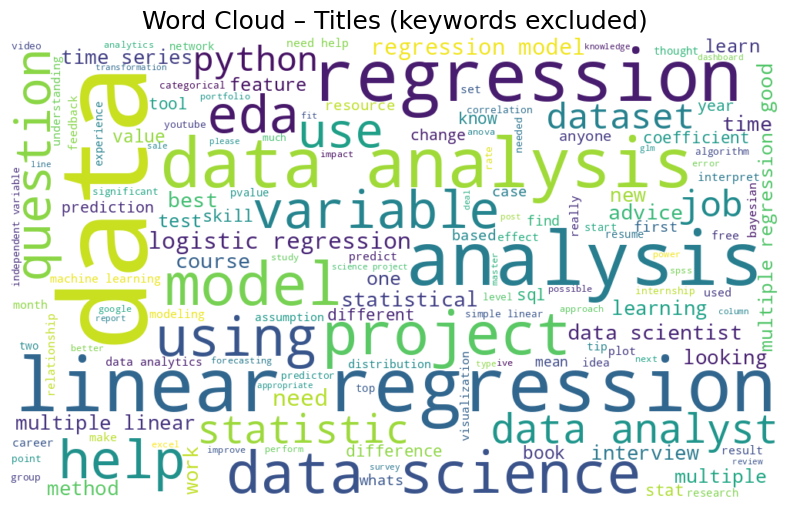

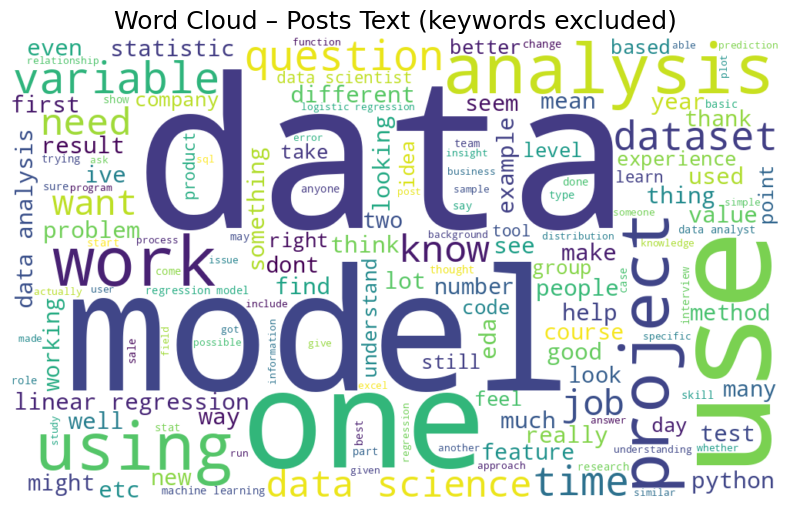

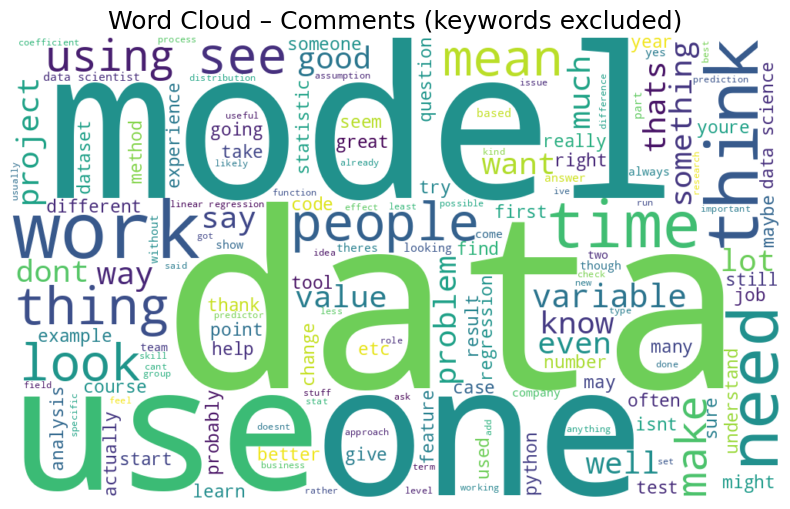

In [ ]:
# === GENERAR LAS TRES NUBES ===
show_wordcloud(titles_text, "Word Cloud – Titles (keywords excluded)")
show_wordcloud(posts_text, "Word Cloud – Posts Text (keywords excluded)")
show_wordcloud(comments_text, "Word Cloud – Comments (keywords excluded)")

#### Nube sin StopWords

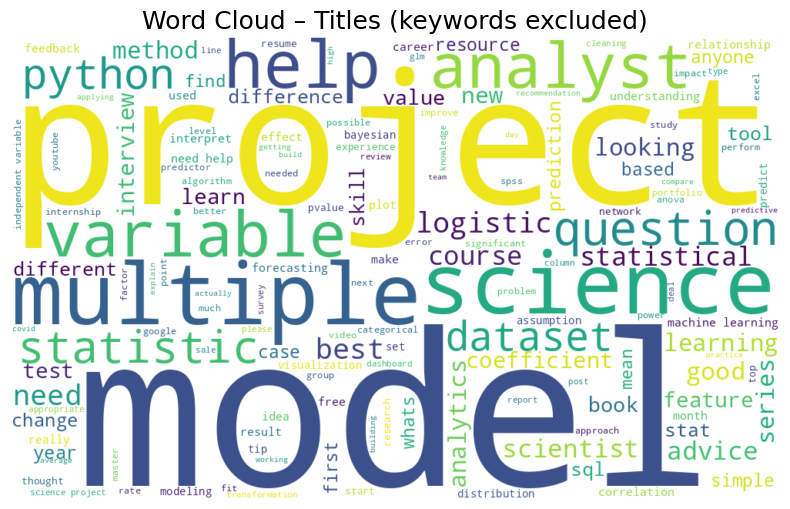

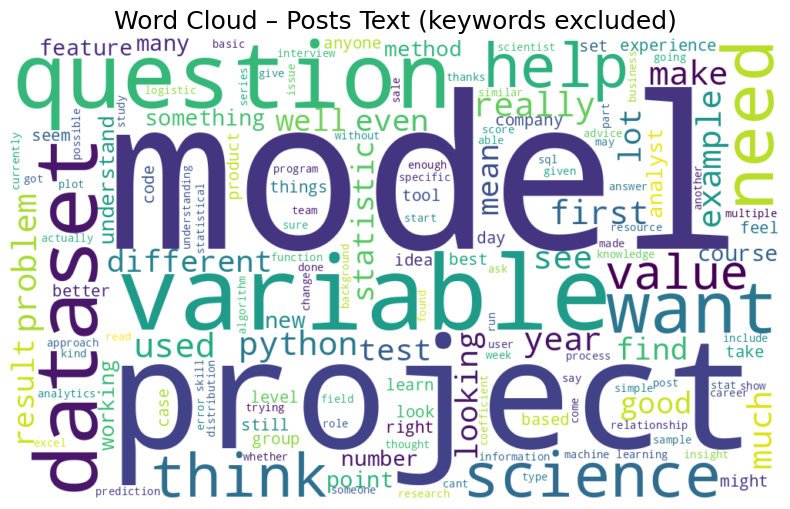

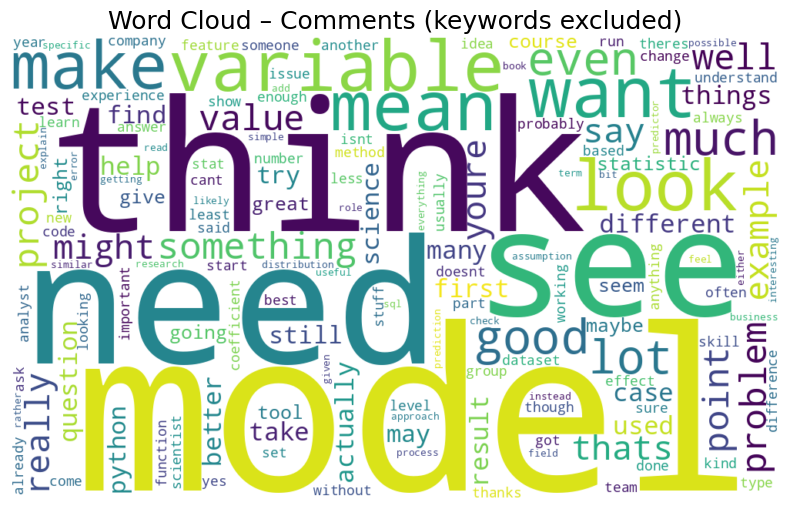

In [ ]:
# === GENERAR LAS TRES NUBES ===
show_wordcloud(titles_text, "Word Cloud – Titles (keywords excluded)")
show_wordcloud(posts_text, "Word Cloud – Posts Text (keywords excluded)")
show_wordcloud(comments_text, "Word Cloud – Comments (keywords excluded)")

### Crear Dataframe

- Crear un dataframe para poder analizar más variables del resultado

In [ ]:
# Create a list of dictionaries with only the desired fields
posts_list = []
for post in posts:
    post_data = {
        "subreddit": post.get("subreddit"),
        "post_id": post.get("post_id"),
        "keyword": post.get("keyword"),
        "title": post.get("title"),
        "text": post.get("text"),
        "score": post.get("score"),
        "flair": post.get("flair"),
        "created_utc": post.get("created_utc"),
        "created_date": post.get("created_date"),
        "num_comments": post.get("num_comments"),
        "post_url": post.get("post_url"),
        "permalink": post.get("permalink"),
        "image_url": post.get("image_url"),
    }
    posts_list.append(post_data)
# Create the pandas DataFrame
df_posts = pd.DataFrame(posts_list)

In [ ]:
df_posts.head()

,subreddit,post_id,keyword,title,text,score,flair,created_utc,created_date,num_comments,post_url,permalink,image_url
0,datascience,f20n3x,EDA,when I start EDA on a new project,,1433,None,1.581384e+09,2020-02-11 01:20:43,9,https://i.redd.it/886thyh557g41.jpg,https://reddit.com/r/datascience/comments/f20n...,https://preview.redd.it/886thyh557g41.jpg?auto...
1,datascience,gf9hrs,EDA,What makes a good personal project - from the ...,"We often see the question on this sub around ""...",653,None,1.588868e+09,2020-05-07 16:13:05,58,https://www.reddit.com/r/datascience/comments/...,https://reddit.com/r/datascience/comments/gf9h...,None
2,datascience,myurtx,EDA,The Journey Of Problem Solving Using Analytics,In my \~6 years of working in the analytics do...,478,Projects,1.619434e+09,2021-04-26 10:40:32,50,https://www.reddit.com/r/datascience/comments/...,https://reddit.com/r/datascience/comments/myur...,None
3,datascience,e2sl1n,EDA,A guided introduction to Exploratory Data Anal...,,309,Education,1.574915e+09,2019-11-28 04:17:09,22,https://blog.growingdata.com.au/a-guided-intro...,https://reddit.com/r/datascience/comments/e2sl...,https://external-preview.redd.it/TtzvkRVK6MSqS...
4,datascience,1fy9jfq,EDA,We are not only model builders! Stop with that!,I would like to share some thoughts I’ve been ...,184,Discussion,1.728313e+09,2024-10-07 14:51:47,36,https://www.reddit.com/r/datascience/comments/...,https://reddit.com/r/datascience/comments/1fy9...,None


In [ ]:
is_post_id_unique = df_posts['post_id'].is_unique
is_post_id_unique

True

In [ ]:
df_posts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1492 entries, 0 to 1491
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   subreddit     1492 non-null   object
 1   post_id       1492 non-null   object
 2   keyword       1492 non-null   object
 3   title         1492 non-null   object
 4   text          1492 non-null   object
 5   score         1492 non-null   int64 
 6   flair         609 non-null    object
 7   created_date  1492 non-null   object
 8   num_comments  1492 non-null   int64 
 9   post_url      1492 non-null   object
 10  permalink     1492 non-null   object
 11  image_url     128 non-null    object
dtypes: int64(2), object(10)
memory usage: 140.0+ KB


### Valores faltantes / Imágenes

In [ ]:
# Analizar cuantas filas tienen cadenas vacías = ""
df_faltantes = df_posts[df_posts['text'] == '']
df_faltantes.shape

(159, 12)

In [ ]:
df_faltantes.head(10)

,subreddit,post_id,keyword,title,text,score,flair,created_date,num_comments,post_url,permalink,image_url
0,datascience,f20n3x,EDA,when I start EDA on a new project,,1433,None,2020-02-11 01:20:43,9,https://i.redd.it/886thyh557g41.jpg,https://reddit.com/r/datascience/comments/f20n...,https://preview.redd.it/886thyh557g41.jpg?auto...
3,datascience,e2sl1n,EDA,A guided introduction to Exploratory Data Anal...,,309,Education,2019-11-28 04:17:09,22,https://blog.growingdata.com.au/a-guided-intro...,https://reddit.com/r/datascience/comments/e2sl...,https://external-preview.redd.it/TtzvkRVK6MSqS...
17,datascience,111bdx7,EDA,Do you use tools for automatic EDA? Which ones...,,63,Discussion,2023-02-13 15:09:19,17,https://i.redd.it/ebndmkmo1zha1.png,https://reddit.com/r/datascience/comments/111b...,https://preview.redd.it/ebndmkmo1zha1.png?auto...
53,datascience,10sviok,EDA,Can Data Science work flows follow agile? How ...,,16,Discussion,2023-02-03 21:16:12,14,https://www.reddit.com/r/datascience/comments/...,https://reddit.com/r/datascience/comments/10sv...,None
160,datascience,13l18d3,Exploratory data analysis,Taipy: easily convert your Data Science Analys...,,329,Tooling,2023-05-18 14:52:24,33,https://i.redd.it/umyz0u9fsl0b1.gif,https://reddit.com/r/datascience/comments/13l1...,https://preview.redd.it/umyz0u9fsl0b1.gif?form...
165,datascience,an1xn9,Exploratory data analysis,"pandas-profiling - Really cool, easy tool to g...",,241,None,2019-02-04 14:02:13,38,https://nbviewer.jupyter.org/github/JosPolflie...,https://reddit.com/r/datascience/comments/an1x...,None
191,datascience,cvcen7,Exploratory data analysis,Data Analysis : What are the outcomes of codin...,,127,Career,2019-08-25 18:44:40,42,https://conductscience.com/data-analysis-what-...,https://reddit.com/r/datascience/comments/cvce...,https://external-preview.redd.it/ZEDrD4_7vjN93...
223,datascience,axc5n8,Regression,Using deep learning to implement linear regres...,,246,RIP Medium,2019-03-04 20:48:24,16,https://twitter.com/MachinePix/status/11023022...,https://reddit.com/r/datascience/comments/axc5...,https://external-preview.redd.it/zdAvysh1DBVw-...
255,datascience,sdxd7u,Regression,"Gelman, Hill, and Vehtari's new book, ""Regress...",,74,Education,2022-01-27 12:33:31,2,https://users.aalto.fi/~ave/ROS.pdf,https://reddit.com/r/datascience/comments/sdxd...,None
261,datascience,c81tc1,Regression,Predicting Academic Collaboration with Logisti...,,67,Projects,2019-07-01 23:32:21,12,https://teddykoker.com/2019/07/predicting-acad...,https://reddit.com/r/datascience/comments/c81t...,https://external-preview.redd.it/oqBWosQDUKQ-C...


In [ ]:
# Chequear si algún post que tiene cadena vacía en text
# si también tiene cadenas vacías en post_url, permalink, image_url
df_posts[(df_posts['text'] == '') & (df_posts['post_url'] == '') & (df_posts['permalink'] == '') & (df_posts['image_url'] == '')]

,subreddit,post_id,keyword,title,text,score,flair,created_utc,created_date,num_comments,post_url,permalink,image_url,year


### Fechas

In [ ]:
df_posts['created_utc'] = pd.to_datetime(df_posts['created_utc'], unit='s')
display(f"Minimum date: {df_posts['created_utc'].min()}")
display(f"Maximum date: {df_posts['created_utc'].max()}")

'Minimum date: 2019-01-10 01:28:15'

'Maximum date: 2025-10-26 07:57:27'

In [ ]:
df_posts['year'] = df_posts['created_utc'].dt.year
yearly_distribution = df_posts['year'].value_counts().sort_index()
display(yearly_distribution)

,count
year,
2019,123
2020,203
2021,204
2022,215
2023,230
2024,247
2025,270


<Axes: xlabel='year', ylabel='Count'>

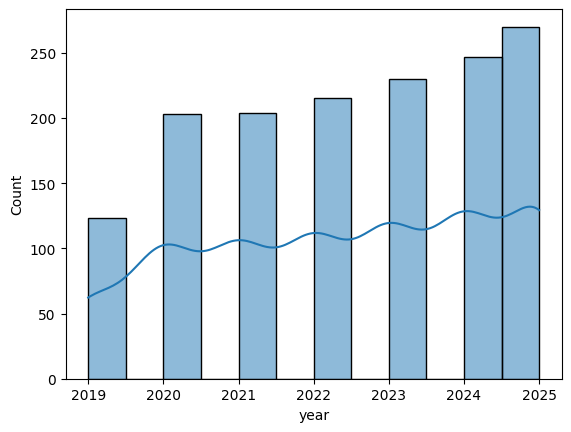

In [ ]:
sns.histplot(df_posts['year'], kde=True)

### Etiquetas

In [ ]:
df_etiquetas = df_posts['flair']

In [ ]:
df_etiquetas.value_counts()

,count
flair,
Discussion,175
OC,124
Data Question,74
Projects,50
Career,45
Education,39
Data Tools,16
Tooling,14
ML,13


### Número de Comentarios

In [ ]:
df_posts['num_comments'].describe()

,num_comments
count,1492.000000
mean,14.378016
std,13.893212
min,1.000000
25%,4.000000
50%,10.000000
75%,20.000000
max,60.000000


<Axes: ylabel='num_comments'>

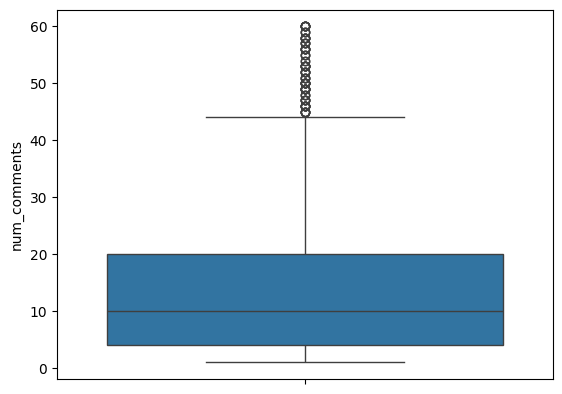

In [ ]:
sns.boxplot(data=df_posts, y='num_comments')

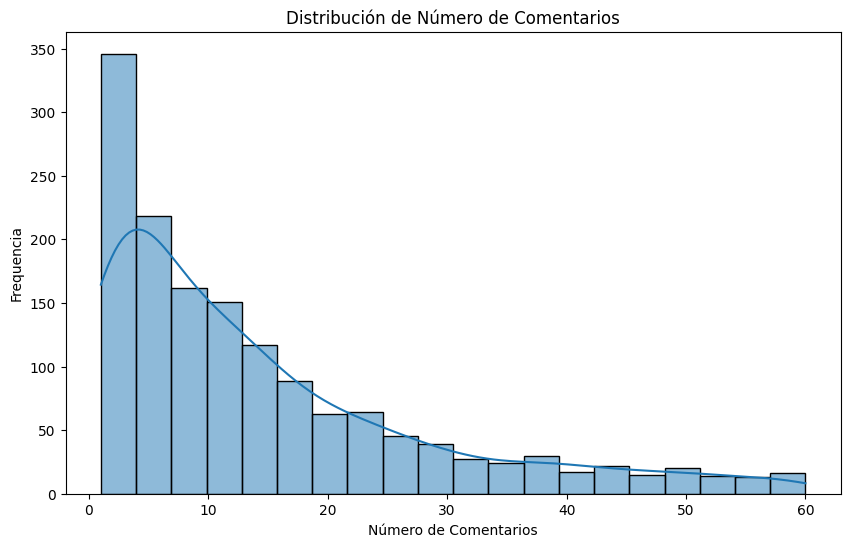

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_posts['num_comments'], bins=20, kde=True)
plt.title('Distribución de Número de Comentarios')
plt.xlabel('Número de Comentarios')
plt.ylabel('Frequencia')
plt.show()

In [ ]:
df_posts['num_comments'].describe()

,num_comments
count,1492.000000
mean,14.378016
std,13.893212
min,1.000000
25%,4.000000
50%,10.000000
75%,20.000000
max,60.000000


In [ ]:
df_posts['num_comments'].value_counts()

,count
num_comments,
1,145
2,117
3,84
4,78
5,76
6,64
7,58
12,57
8,56


In [ ]:
# Distribución de posts por intervalos de 'num_comments' (intervalos de 10)
comment_intervals = df_posts.groupby(pd.cut(df_posts['num_comments'], bins=range(0, 61, 10))).size()

display(comment_intervals)

/tmp/ipython-input-4023084591.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  comment_intervals = df_posts.groupby(pd.cut(df_posts['num_comments'], bins=range(0, 61, 10))).size()


,0
num_comments,
"(0, 10]",777
"(10, 20]",356
"(20, 30]",161
"(30, 40]",87
"(40, 50]",64
"(50, 60]",47


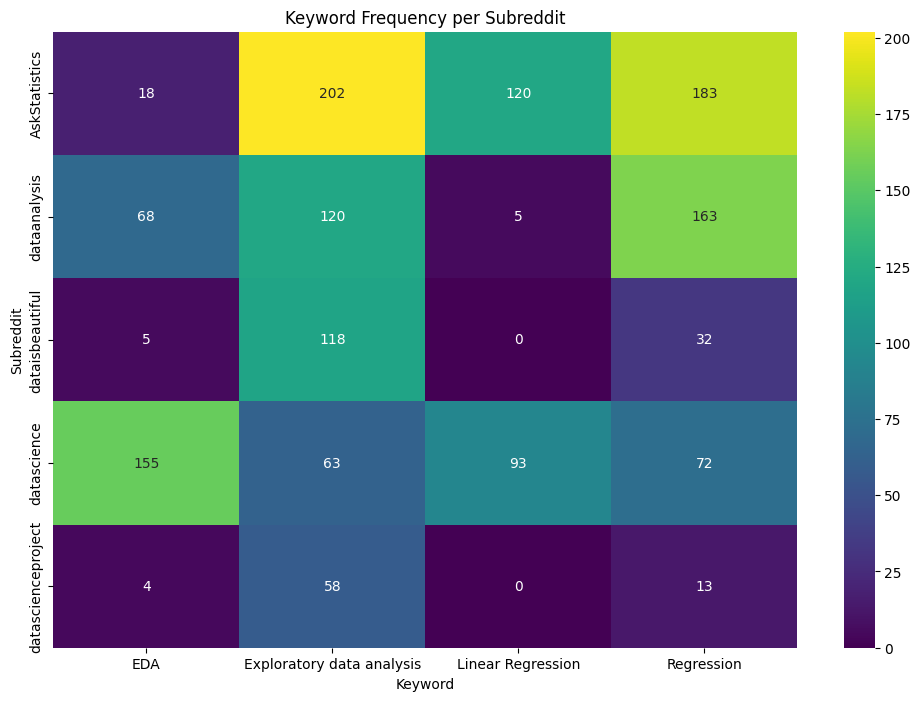

Crosstab of Subreddits and Keywords:
keyword             EDA  Exploratory data analysis  Linear Regression  \
subreddit                                                               
AskStatistics        18                        202                120   
dataanalysis         68                        120                  5   
dataisbeautiful       5                        118                  0   
datascience         155                         63                 93   
datascienceproject    4                         58                  0   

keyword             Regression  
subreddit                       
AskStatistics              183  
dataanalysis               163  
dataisbeautiful             32  
datascience                 72  
datascienceproject          13  


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# === ANALYZE AND VISUALIZE SUBREDDIT AND KEYWORD GROUPING ===

# Create a crosstab to see the frequency of keywords per subreddit
# A crosstab is a table that shows the frequency distribution of variables.
subreddit_keyword_crosstab = pd.crosstab(df_posts['subreddit'], df_posts['keyword'])

# Plotting the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(subreddit_keyword_crosstab, annot=True, cmap="viridis", fmt='d')

# Adding titles and labels for clarity
plt.title('Keyword Frequency per Subreddit')
plt.xlabel('Keyword')
plt.ylabel('Subreddit')

# Display the plot
plt.show()

# You can also print the crosstab table to see the raw counts
print("Crosstab of Subreddits and Keywords:")
print(subreddit_keyword_crosstab)

### Aportación por Subreddit

In [ ]:
# Post totales de cada subreddit
subreddit_counts = df_posts['subreddit'].value_counts()
subreddit_counts

,count
subreddit,
AskStatistics,523
datascience,383
dataanalysis,356
dataisbeautiful,155
datascienceproject,75


In [ ]:
subreddit_yearly_distribution = df_posts.groupby('subreddit')['year'].value_counts().unstack(fill_value=0)
display(subreddit_yearly_distribution)

year,2019,2020,2021,2022,2023,2024,2025
subreddit,,,,,,,
AskStatistics,34,102,116,72,51,78,70
dataanalysis,6,20,30,66,76,84,74
dataisbeautiful,20,25,8,4,11,21,66
datascience,61,50,49,69,77,51,26
datascienceproject,2,6,1,4,15,13,34


### Longitud de texto

In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np

# === CARGA DEL DATASET ===
with open("/content/reddit_dataset_final_20251027_015525_1492_posts.json", "r", encoding="utf-8") as f:
    data = json.load(f)

In [ ]:
# === CONVERSIÓN A DATAFRAME PLANO (posts y comentarios) ===
posts = []
comments = []

for post in data:
    post_row = {
        "post_id": post["post_id"],
        "title": post["title"],
        "text": post["text"],
        "num_comments": post["num_comments"],
        "keyword": post["keyword"],
        "flair": post["flair"]
    }
    posts.append(post_row)

    for comment in post["comments"]:
        comments.append({
            "post_id": post["post_id"],
            "comment_id": comment["comment_id"],
            "text": comment["text"]
        })

df_posts = pd.DataFrame(posts)
df_comments = pd.DataFrame(comments)


In [ ]:
# Longitud de texto en 'Title'

📊 Estadísticas de longitud:

--- Title ---
count    1492.000000
mean       68.335121
std        42.623320
min         6.000000
25%        41.000000
50%        60.000000
75%        83.000000
max       300.000000
Name: title_length, dtype: float64


Text(0, 0.5, 'Frecuencia')

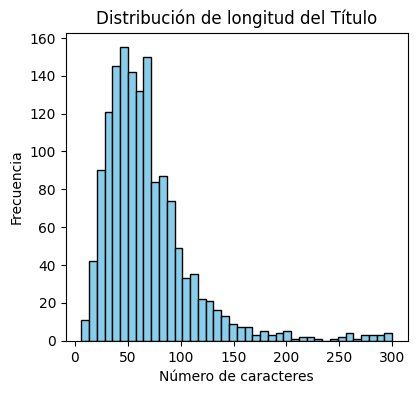

In [ ]:
df_posts["title_length"] = df_posts["title"].apply(lambda x: len(x.strip()) if isinstance(x, str) else 0)
# === ESTADÍSTICAS ===
print("📊 Estadísticas de longitud:")
print("\n--- Title ---")
print(df_posts["title_length"].describe())

# === HISTOGRAMAS ===
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(df_posts["title_length"], bins=40, color="skyblue", edgecolor="black")
plt.title("Distribución de longitud del Título")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")


📊 Distribución de tokens en títulos:
count    1492.000000
mean       13.867962
std         9.487646
min         1.000000
25%         8.000000
50%        12.000000
75%        17.000000
max        73.000000
Name: num_tokens, dtype: float64


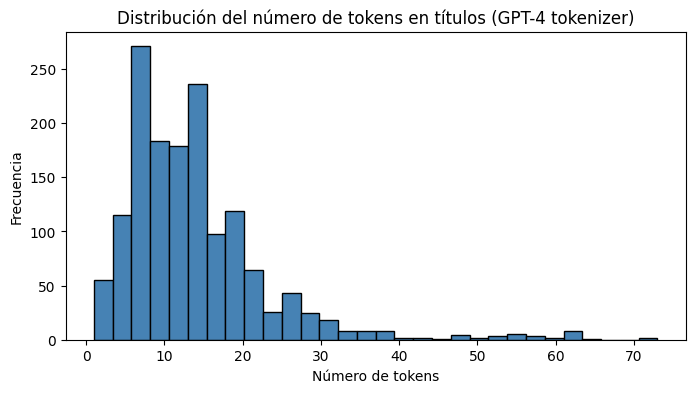


🔍 Ejemplo de títulos muy largos (>40 tokens): 34 encontrados

['I build a predictive model but the prediction is very off on the test dataset...most of the predictions are way lower than the actual value. Do I need to select a new modelling technique? I am using linear regression.', 'I have completed my certification in Data Analysis with IBM on coursera I started connecting on Linkedin with recruiters and reached out to them and applied for more than 250 jobs in different analysis fields but didn’t get a single call back, and suggestions or updates that i need to do?', "[OC] Interesting plot aggregating states' Covid-19 per-capita new cases with average I.Q. for state. I am aggregating data from several public sources listed in comments. I am not suggesting any analysis, only showing the results of plotting public data. Full source code available at link.", 'New to this so have mercy. Just finished data analytics course. Used comments to a post I made in r/standardissuecat. Weird hum

In [ ]:
import tiktoken

# === EXTRAER TITULOS ===
titles = [post["title"] for post in data if isinstance(post["title"], str)]

# === SELECCIONAR TOKENIZADOR (puedes cambiar el modelo)
encoding = tiktoken.encoding_for_model("gpt-4o")

# === CONTAR TOKENS POR TÍTULO ===
token_counts = [len(encoding.encode(title)) for title in titles]

# === CREAR DATAFRAME ===
df_tokens = pd.DataFrame({"title": titles, "num_tokens": token_counts})

# === ESTADÍSTICAS ===
print("📊 Distribución de tokens en títulos:")
print(df_tokens["num_tokens"].describe())

# === HISTOGRAMA ===
plt.figure(figsize=(8,4))
plt.hist(df_tokens["num_tokens"], bins=30, color="steelblue", edgecolor="black")
plt.title("Distribución del número de tokens en títulos (GPT-4 tokenizer)")
plt.xlabel("Número de tokens")
plt.ylabel("Frecuencia")
plt.show()

# === DETECCIÓN DE EXTREMOS ===
max_tokens = df_tokens["num_tokens"].max()
long_titles = df_tokens[df_tokens["num_tokens"] > 40]  # Ajusta el umbral
print(f"\n🔍 Ejemplo de títulos muy largos (>40 tokens): {len(long_titles)} encontrados\n")
print(long_titles.sample(5, random_state=42)["title"].tolist())

In [ ]:
# Longitud de texto en 'Text'


--- Text ---
count     1492.000000
mean      1081.678284
std       1713.441093
min          0.000000
25%        350.000000
50%        711.500000
75%       1283.500000
max      27330.000000
Name: text_length, dtype: float64


Text(0.5, 0, 'Número de caracteres')

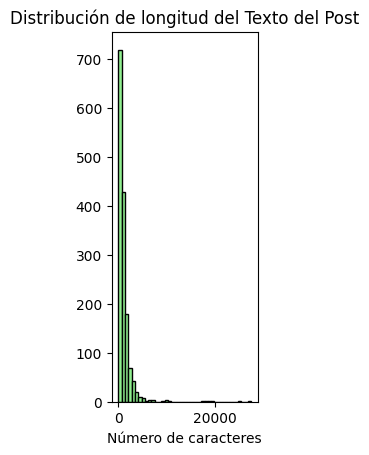

In [ ]:
df_posts["text_length"] = df_posts["text"].apply(lambda x: len(x.strip()) if isinstance(x, str) else 0)
print("\n--- Text ---")
print(df_posts["text_length"].describe())

plt.subplot(1, 3, 2)
plt.hist(df_posts["text_length"], bins=40, color="lightgreen", edgecolor="black")
plt.title("Distribución de longitud del Texto del Post")
plt.xlabel("Número de caracteres")

In [ ]:
import json
import pandas as pd
import tiktoken
import matplotlib.pyplot as plt

# === CARGAR EL DATASET ===
with open("reddit_dataset_20251012_2139_posts.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# === TOKENIZADOR ===
# Puedes usar "gpt-4o", "gpt-3.5-turbo", etc. según el modelo con el que planees trabajar
encoding = tiktoken.encoding_for_model("gpt-4o-mini")

# === EXTRAER DATOS ===
titles = [post["title"] for post in data if isinstance(post.get("title"), str)]
texts = [post["text"] for post in data if isinstance(post.get("text"), str)]
comments = [comment["text"]
            for post in data if "comments" in post
            for comment in post["comments"]
            if isinstance(comment.get("text"), str)]

# === FUNCIÓN PARA CONTAR TOKENS ===
def count_tokens(texts):
    return [len(encoding.encode(t)) for t in texts]

# === CALCULAR TOKENS ===
title_tokens = count_tokens(titles)
text_tokens = count_tokens(texts)
comment_tokens = count_tokens(comments)

# === CREAR DATAFRAMES ===
df_titles = pd.DataFrame({"type": "title", "num_tokens": title_tokens})
df_texts = pd.DataFrame({"type": "text", "num_tokens": text_tokens})
df_comments = pd.DataFrame({"type": "comment", "num_tokens": comment_tokens})

# === UNIR ===
df_all = pd.concat([df_titles, df_texts, df_comments])

# === ESTADÍSTICAS GLOBALES ===
print("📊 Estadísticas de tokens:")
for ttype in ["title", "text", "comment"]:
    subset = df_all[df_all["type"] == ttype]["num_tokens"]
    print(f"\n--- {ttype.upper()} ---")
    print(subset.describe())

# === VISUALIZACIONES ===
plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.hist(df_titles["num_tokens"], bins=30, color="skyblue", edgecolor="black")
plt.title("Distribución de tokens en títulos")
plt.xlabel("Tokens")
plt.ylabel("Frecuencia")

plt.subplot(1,3,2)
plt.hist(df_texts["num_tokens"], bins=30, color="lightgreen", edgecolor="black")
plt.title("Distribución de tokens en textos (posts)")
plt.xlabel("Tokens")

plt.subplot(1,3,3)
plt.hist(df_comments["num_tokens"], bins=30, color="salmon", edgecolor="black")
plt.title("Distribución de tokens en comentarios")
plt.xlabel("Tokens")

plt.tight_layout()
plt.show()

# === RELACIÓN ENTRE CAMPOS ===
summary = df_all.groupby("type")["num_tokens"].agg(["mean", "std", "median", "max", "min", "count"])
print("\n📈 Resumen comparativo por tipo de texto:")
print(summary)

# === TÍTULOS EXTREMOS ===
long_titles = [t for t, n in zip(titles, title_tokens) if n > 40]
print(f"\n🔍 Ejemplo de títulos muy largos (>40 tokens): {len(long_titles)} encontrados\n")
print(long_titles[:5])


In [ ]:
# Longitud de texto en 'Comments'

In [ ]:
df_comments["comment_length"] = df_comments["text"].apply(lambda x: len(x.strip()) if isinstance(x, str) else 0)
print("\n--- Comments ---")
print(df_comments["comment_length"].describe())


plt.subplot(1, 3, 3)
plt.hist(df_comments["comment_length"], bins=40, color="salmon", edgecolor="black")
plt.title("Distribución de longitud de Comentarios")
plt.xlabel("Número de caracteres")


In [ ]:
# === RELACIÓN ENTRE LONGITUD Y NÚMERO DE COMENTARIOS ===
plt.figure(figsize=(6, 5))
plt.scatter(df_posts["text_length"], df_posts["num_comments"], alpha=0.5)
plt.title("Relación entre longitud del texto del post y número de comentarios")
plt.xlabel("Longitud del texto del post")
plt.ylabel("Número de comentarios")
plt.show()


# Vectorial Database

## Preprocesamiento

In [ ]:
import json
import re
import uuid
from typing import List, Dict, Tuple

# --- CONFIGURATION ---
MIN_SCORE_COMMENT = 1
MIN_WORDS_COMMENT = 5
DELETED_COMMENT = ['[deleted]', '[removed]']





FILE_PATH = '/content/reddit_dataset_final_1492_posts.json'
BATCH_SIZE = 100

url_pattern = re.compile(r'(https?://\S+)')


def clean_and_extract_urls(text: str) -> Tuple[str, List[str]]:
    """
    Removes URLs from text and returns cleaned text with extracted URLs.

    Args:
        text: Input text containing potential URLs

    Returns:
        Tuple of (cleaned_text, list_of_urls)
    """
    if not text:
        return "", []

    urls = url_pattern.findall(text)
    clean_text = url_pattern.sub('', text).replace('  ', ' ').strip()
    return clean_text, urls


def preprocess_dataset(file_path: str) -> Tuple[List[str], List[str], List[Dict]]:
    """
    Preprocesses Reddit dataset and prepares data for ChromaDB insertion.

    Args:
        file_path: Path to the JSON file containing Reddit posts

    Returns:
        Tuple of (ids, documents, metadatas) ready for ChromaDB insertion
    """
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    ids = []
    documents = []
    metadatas = []

    stats = {
        'posts': 0,
        'comments': 0,
        'skipped_empty': 0,
        'skipped_deleted': 0
    }

    print(f"Starting preprocessing of {len(data)} posts...")

    for post in data:
        post_id = post.get('post_id', str(uuid.uuid4()))
        p_title = post.get('title', '').strip()
        p_text = post.get('text', '')

        # Skip deleted or removed posts
        if p_text in ['[deleted]', '[removed]', 'comment deleted', 'thank you']:
            stats['skipped_deleted'] += 1
            continue

        p_clean_text, p_urls = clean_and_extract_urls(p_text)

        # Validate: Skip if both title and content are empty
        if not p_title and not p_clean_text:
            stats['skipped_empty'] += 1
            continue

        # Construct post document
        post_doc_content = f"Title: {p_title}\nContent: {p_clean_text}".strip()

        ids.append(f"post_{post_id}")
        documents.append(post_doc_content)
        metadatas.append({
            "type": "post",
            "subreddit": post.get('subreddit', 'unknown'),
            "score": post.get('score', 0),
            "author": post.get('author', 'unknown'),
            "url_source": post.get('post_url', ''),
            "extracted_urls": ", ".join(p_urls),
            "post_title": p_title
        })
        stats['posts'] += 1

        # Process comments
        if 'comments' in post and isinstance(post['comments'], list):
            for comment in post['comments']:
                c_text = comment.get('text', '')
                c_score = comment.get('score', 0)
                c_id = comment.get('comment_id', str(uuid.uuid4()))

                # Filter comments
                if c_text in ['[deleted]', '[removed]']:
                    continue
                if c_score < MIN_SCORE_COMMENT:
                    continue
                if len(c_text.split()) < MIN_WORDS_COMMENT:
                    continue

                c_clean_text, c_urls = clean_and_extract_urls(c_text)

                # Skip if cleaning removed all content
                if not c_clean_text:
                    stats['skipped_empty'] += 1
                    continue

                full_comment_doc = f"Context (Post Title): {p_title}\nComment: {c_clean_text}"

                ids.append(f"comment_{c_id}")
                documents.append(full_comment_doc)
                metadatas.append({
                    "type": "comment",
                    "parent_id": post_id,
                    "subreddit": post.get('subreddit', 'unknown'),
                    "score": c_score,
                    "author": comment.get('author', 'unknown'),
                    "post_title": p_title,
                    "extracted_urls": ", ".join(c_urls)
                })
                stats['comments'] += 1

    print("\nPreprocessing Complete:")
    print(f"  Posts: {stats['posts']}")
    print(f"  Comments: {stats['comments']} (score ≥ {MIN_SCORE_COMMENT})")
    print(f"  Skipped (empty): {stats['skipped_empty']}")
    print(f"  Skipped (deleted): {stats['skipped_deleted']}")
    print(f"  Total documents: {len(documents)}")

    return ids, documents, metadatas

In [ ]:
ids, documents, metadatas = preprocess_dataset(FILE_PATH)
print(f"\nReady to insert {len(ids)} documents into ChromaDB.")

Starting preprocessing of 1492 posts...

Preprocessing Complete:
  Posts: 1492
  Comments: 18022 (score ≥ 1)
  Skipped (empty): 1
  Skipped (deleted): 0
  Total documents: 19514

Ready to insert 19514 documents into ChromaDB.


### Visualizar resultado

In [ ]:
def preview_preprocessed_data(ids: List[str], documents: List[str],
                             metadatas: List[Dict], num_samples: int = 5):
    """
    Displays a preview of preprocessed data before insertion.

    Args:
        ids: List of document IDs
        documents: List of document texts
        metadatas: List of metadata dictionaries
        num_samples: Number of samples to display
    """
    print("\n" + "="*80)
    print("PREPROCESSED DATA PREVIEW")
    print("="*80)

    # Overall statistics
    total = len(ids)
    posts = sum(1 for m in metadatas if m['type'] == 'post')
    comments = sum(1 for m in metadatas if m['type'] == 'comment')

    print(f"\n📊 DATASET SUMMARY:")
    print(f"  Total documents: {total}")
    print(f"  Posts: {posts}")
    print(f"  Comments: {comments}")

    # Document length statistics
    doc_lengths = [len(doc.split()) for doc in documents]
    avg_length = sum(doc_lengths) / len(doc_lengths) if doc_lengths else 0
    min_length = min(doc_lengths) if doc_lengths else 0
    max_length = max(doc_lengths) if doc_lengths else 0

    print(f"\n📏 DOCUMENT LENGTH (words):")
    print(f"  Average: {avg_length:.1f}")
    print(f"  Min: {min_length}")
    print(f"  Max: {max_length}")

    # Subreddit distribution
    subreddits = {}
    for m in metadatas:
        sub = m.get('subreddit', 'unknown')
        subreddits[sub] = subreddits.get(sub, 0) + 1

    print(f"\n📍 TOP SUBREDDITS:")
    for sub, count in sorted(subreddits.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  {sub}: {count} documents")

    # Sample documents
    print(f"\n📄 SAMPLE DOCUMENTS (showing {min(num_samples, total)}):")
    print("-"*80)

    for i in range(min(num_samples, total)):
        print(f"\n[{i+1}] ID: {ids[i]}")
        print(f"Type: {metadatas[i]['type'].upper()}")
        print(f"Subreddit: {metadatas[i]['subreddit']}")
        print(f"Score: {metadatas[i]['score']}")
        print(f"Author: {metadatas[i]['author']}")

        if metadatas[i].get('extracted_urls'):
            print(f"URLs: {metadatas[i]['extracted_urls'][:100]}...")

        # Truncate long documents for preview
        doc_preview = documents[i][:300] + "..." if len(documents[i]) > 300 else documents[i]
        print(f"\nContent:\n{doc_preview}")
        print("-"*80)

    print(f"\n✅ Preview complete. Ready to insert {total} documents.")
    print("="*80 + "\n")

In [ ]:
preview_preprocessed_data(ids, documents, metadatas, num_samples=10)


PREPROCESSED DATA PREVIEW

📊 DATASET SUMMARY:
  Total documents: 8722
  Posts: 1492
  Comments: 7230

📏 DOCUMENT LENGTH (words):
  Average: 103.5
  Min: 4
  Max: 4292

📍 TOP SUBREDDITS:
  datascience: 3606 documents
  AskStatistics: 2347 documents
  dataanalysis: 1482 documents
  dataisbeautiful: 1209 documents
  datascienceproject: 78 documents

📄 SAMPLE DOCUMENTS (showing 10):
--------------------------------------------------------------------------------

[1] ID: post_f20n3x
Type: POST
Subreddit: datascience
Score: 1433
Author: jonboighini

Content:
Title: when I start EDA on a new project
Content:
--------------------------------------------------------------------------------

[2] ID: comment_fha17a0
Type: COMMENT
Subreddit: datascience
Score: 77
Author: setocsheir

Content:
Context (Post Title): when I start EDA on a new project
Comment: i'm not sure what an ordinal variable tastes like but i'd sure like to find out
--------------------------------------------------------------

In [ ]:
def save_preprocessed_data(ids: List[str], documents: List[str],
                          metadatas: List[Dict], output_path: str = 'preprocessed_data.json'):
    """
    Saves preprocessed data to a JSON file for manual inspection.

    Args:
        ids: List of document IDs
        documents: List of document texts
        metadatas: List of metadata dictionaries
        output_path: Path to save the JSON file
    """
    # Combine all data into structured format
    structured_data = []

    for i in range(len(ids)):
        structured_data.append({
            "id": ids[i],
            "document": documents[i],
            "metadata": metadatas[i],
            "word_count": len(documents[i].split()),
            "char_count": len(documents[i])
        })

    # Create summary statistics
    summary = {
        "total_documents": len(ids),
        "posts": sum(1 for m in metadatas if m['type'] == 'post'),
        "comments": sum(1 for m in metadatas if m['type'] == 'comment'),
        "average_word_count": sum(d['word_count'] for d in structured_data) / len(structured_data) if structured_data else 0,
        "subreddits": {},
        "authors": {}
    }

    # Count subreddits and authors
    for m in metadatas:
        sub = m.get('subreddit', 'unknown')
        author = m.get('author', 'unknown')
        summary['subreddits'][sub] = summary['subreddits'].get(sub, 0) + 1
        summary['authors'][author] = summary['authors'].get(author, 0) + 1

    # Sort by count
    summary['subreddits'] = dict(sorted(summary['subreddits'].items(), key=lambda x: x[1], reverse=True))
    summary['top_10_authors'] = dict(sorted(summary['authors'].items(), key=lambda x: x[1], reverse=True)[:10])
    del summary['authors']  # Remove full author list to keep file size manageable

    # Create final output structure
    output = {
        "summary": summary,
        "documents": structured_data
    }

    # Save to file
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(output, f, indent=2, ensure_ascii=False)

    print(f"\n💾 Preprocessed data saved to: {output_path}")
    print(f"   Total size: {len(json.dumps(output)) / 1024 / 1024:.2f} MB")
    print(f"   Documents: {len(structured_data)}")
    print(f"\n📝 You can now inspect the JSON file for anomalies before insertion.")

    return output_path

In [ ]:
save_preprocessed_data(ids, documents, metadatas, output_path='my_data.json')


💾 Preprocessed data saved to: my_data.json
   Total size: 8.08 MB
   Documents: 8722

📝 You can now inspect the JSON file for anomalies before insertion.


'my_data.json'

# Carga de Documentos

In [ ]:
!pip install chromadb


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 1.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0/220.0 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.6 MB/s eta 0:

In [ ]:
!pip install openai

In [ ]:
def insert_to_chromadb(collection, ids: List[str], documents: List[str],
                       metadatas: List[Dict], batch_size: int = BATCH_SIZE):
    """
    Inserts preprocessed data into ChromaDB collection in batches.

    Args:
        collection: ChromaDB collection object
        ids: List of document IDs
        documents: List of document texts
        metadatas: List of metadata dictionaries
        batch_size: Number of documents per batch
    """
    total = len(ids)
    print(f"\nInserting {total} documents into ChromaDB in batches of {batch_size}...")

    for i in range(0, total, batch_size):
        batch_ids = ids[i:i + batch_size]
        batch_docs = documents[i:i + batch_size]
        batch_metas = metadatas[i:i + batch_size]

        collection.upsert(
            ids=batch_ids,
            documents=batch_docs,
            metadatas=batch_metas
        )

        print(f"  Inserted batch {i // batch_size + 1}/{(total + batch_size - 1) // batch_size}")

    print("Insertion complete!")

In [ ]:
import chromadb
from chromadb.utils import embedding_functions
from google.colab import userdata


ef = embedding_functions.GoogleGenerativeAiEmbeddingFunction(
    api_key="-------"
)

client = chromadb.PersistentClient(path="/chroma_db_gem")
collection_name = "reddit_datascience_openai"
collection = client.get_or_create_collection(
    name=collection_name,
    embedding_function=ef
)

# TEST

In [ ]:
import json
import re
import uuid
from typing import List, Dict, Tuple

# --- CONFIGURATION ---
FILE_PATH = 'reddit_dataset_final_1492_posts.json'
MIN_SCORE_COMMENT = 3
MIN_WORDS_COMMENT = 5
SUBSAMPLE_SIZE = 50  # Number of documents to process

url_pattern = re.compile(r'(https?://\S+)')


def clean_and_extract_urls(text: str) -> Tuple[str, List[str]]:
    """
    Removes URLs from text and returns cleaned text with extracted URLs.

    Args:
        text: Input text containing potential URLs

    Returns:
        Tuple of (cleaned_text, list_of_urls)
    """
    if not text:
        return "", []

    urls = url_pattern.findall(text)
    clean_text = url_pattern.sub('', text).replace('  ', ' ').strip()
    return clean_text, urls


def preprocess_dataset_subsample(file_path: str, subsample_size: int = SUBSAMPLE_SIZE) -> Tuple[List[str], List[str], List[Dict]]:
    """
    Preprocesses Reddit dataset (SUBSAMPLE ONLY) and prepares data for ChromaDB insertion.

    Args:
        file_path: Path to the JSON file containing Reddit posts
        subsample_size: Maximum number of documents to process

    Returns:
        Tuple of (ids, documents, metadatas) ready for ChromaDB insertion
    """
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    ids = []
    documents = []
    metadatas = []

    stats = {
        'posts': 0,
        'comments': 0,
        'skipped_empty': 0,
        'skipped_deleted': 0
    }

    print(f"Starting preprocessing (SUBSAMPLE: {subsample_size} documents max)...")
    print(f"Total posts in dataset: {len(data)}")

    for post in data:
        # Stop if we've reached the subsample limit
        if len(documents) >= subsample_size:
            print(f"\n⚠️  Reached subsample limit of {subsample_size} documents. Stopping.")
            break

        post_id = post.get('post_id', str(uuid.uuid4()))
        p_title = post.get('title', '').strip()
        p_text = post.get('text', '')

        # Skip deleted or removed posts
        if p_text in ['[deleted]', '[removed]']:
            stats['skipped_deleted'] += 1
            continue

        p_clean_text, p_urls = clean_and_extract_urls(p_text)

        # Validate: Skip if both title and content are empty
        if not p_title and not p_clean_text:
            stats['skipped_empty'] += 1
            continue

        # Construct post document
        post_doc_content = f"Title: {p_title}\nContent: {p_clean_text}".strip()

        ids.append(f"post_{post_id}")
        documents.append(post_doc_content)
        metadatas.append({
            "type": "post",
            "subreddit": post.get('subreddit', 'unknown'),
            "score": post.get('score', 0),
            "author": post.get('author', 'unknown'),
            "url_source": post.get('post_url', ''),
            "extracted_urls": ", ".join(p_urls),
            "post_title": p_title
        })
        stats['posts'] += 1

        # Process comments (only if we haven't hit the limit)
        if 'comments' in post and isinstance(post['comments'], list):
            for comment in post['comments']:
                if len(documents) >= subsample_size:
                    break

                c_text = comment.get('text', '')
                c_score = comment.get('score', 0)
                c_id = comment.get('comment_id', str(uuid.uuid4()))

                # Filter comments
                if c_text in ['[deleted]', '[removed]']:
                    continue
                if c_score < MIN_SCORE_COMMENT:
                    continue
                if len(c_text.split()) < MIN_WORDS_COMMENT:
                    continue

                c_clean_text, c_urls = clean_and_extract_urls(c_text)

                # Skip if cleaning removed all content
                if not c_clean_text:
                    stats['skipped_empty'] += 1
                    continue

                full_comment_doc = f"Context (Post Title): {p_title}\nComment: {c_clean_text}"

                ids.append(f"comment_{c_id}")
                documents.append(full_comment_doc)
                metadatas.append({
                    "type": "comment",
                    "parent_id": post_id,
                    "subreddit": post.get('subreddit', 'unknown'),
                    "score": c_score,
                    "author": comment.get('author', 'unknown'),
                    "post_title": p_title,
                    "extracted_urls": ", ".join(c_urls)
                })
                stats['comments'] += 1

    print("\n" + "="*80)
    print("SUBSAMPLE PREPROCESSING COMPLETE")
    print("="*80)
    print(f"  Posts: {stats['posts']}")
    print(f"  Comments: {stats['comments']} (score ≥ {MIN_SCORE_COMMENT})")
    print(f"  Total documents: {len(documents)}")
    print(f"  Skipped (empty): {stats['skipped_empty']}")
    print(f"  Skipped (deleted): {stats['skipped_deleted']}")

    return ids, documents, metadatas


def insert_to_chromadb(collection, ids: List[str], documents: List[str],
                       metadatas: List[Dict], batch_size: int = 100):
    """
    Inserts preprocessed data into ChromaDB collection in batches.

    Args:
        collection: ChromaDB collection object
        ids: List of document IDs
        documents: List of document texts
        metadatas: List of metadata dictionaries
        batch_size: Number of documents per batch
    """
    total = len(ids)
    print(f"\nInserting {total} documents into ChromaDB...")

    for i in range(0, total, batch_size):
        batch_ids = ids[i:i + batch_size]
        batch_docs = documents[i:i + batch_size]
        batch_metas = metadatas[i:i + batch_size]

        collection.upsert(
            ids=batch_ids,
            documents=batch_docs,
            metadatas=batch_metas
        )

        print(f"  Inserted batch {i // batch_size + 1}/{(total + batch_size - 1) // batch_size}")

    print("✅ Insertion complete!")


if __name__ == "__main__":
    # Preprocess subsample
    ids, documents, metadatas = preprocess_dataset_subsample(FILE_PATH, subsample_size=50)

    print(f"\n🎯 SUBSAMPLE READY: {len(ids)} documents prepared for ChromaDB")
    print("\nTo insert into ChromaDB, run:")
    print("  insert_to_chromadb(collection, ids, documents, metadatas)")

In [ ]:
insert_to_chromadb(collection, ids, documents, metadatas)

In [ ]:
# --- QUERY ---
query_text = "How do I build a portfolio?"  # Change this to test different topics

results = collection.query(
    query_texts=[query_text],
    n_results=5,
    include=["documents", "metadatas", "distances"] # <--- Request distances explicitly
)

# --- DISPLAY RESULTS WITH SCORES ---
print(f"\nQuery: '{query_text}'")
print("-" * 50)

for i in range(len(results['documents'][0])):
    doc = results['documents'][0][i]
    meta = results['metadatas'][0][i]
    score = results['distances'][0][i] # <--- Get the score

    print(f"Result #{i+1}")
    print(f"Score (Distance): {score:.4f}")
    print(f"Type: {meta.get('type')} | Subreddit: {meta.get('subreddit')}")
    print(f"Content Preview: {doc[:150]}...") # Show first 150 chars
    print("-" * 50)


Query: 'How do I build a portfolio?'
--------------------------------------------------
Result #1
Score (Distance): 0.9780  (Lower is better)
Type: comment | Subreddit: datascience
Content Preview: Context (Post Title): What makes a good personal project - from the perspective of a hiring manager
Comment: This is my opinion, and certainly not sha...
--------------------------------------------------
Result #2
Score (Distance): 0.9821  (Lower is better)
Type: comment | Subreddit: datascience
Content Preview: Context (Post Title): What makes a good personal project - from the perspective of a hiring manager
Comment: This is great stuff. This should be pinne...
--------------------------------------------------
Result #3
Score (Distance): 1.0465  (Lower is better)
Type: comment | Subreddit: datascience
Content Preview: Context (Post Title): What makes a good personal project - from the perspective of a hiring manager
Comment: A somewhat related question:
As someone n...
-----------------

### Documentos con muchas palabras (pre-inserción)

In [ ]:
# analyze_length.py
import json
import statistics
from collections import Counter

INPUT_JSON_PATH = '/content/processed_documents_v3.json'

def analyze_length_distribution(file_path: str):
    """Analyze document lengths and identify problematic cases."""

    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            documents = json.load(f)
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
        return

    # Separate posts and comments
    posts = [doc for doc in documents if doc['metadata']['type'] == 'post']
    comments = [doc for doc in documents if doc['metadata']['type'] == 'comment']

    # Calculate word counts
    post_lengths = [(doc['id'], len(doc['document'].split()), doc['metadata']['votes'], doc['metadata']['post_title'][:80])
                    for doc in posts]
    comment_lengths = [(doc['id'], len(doc['document'].split()), doc['metadata']['votes'], doc['metadata']['post_title'][:80])
                       for doc in comments]

    print("="*80)
    print("DOCUMENT LENGTH ANALYSIS")
    print("="*80)

    # Posts analysis
    print("\n📄 POSTS LENGTH DISTRIBUTION:")
    post_words = [length for _, length, _, _ in post_lengths]

    print(f"  Total posts: {len(posts):,}")
    print(f"  Min:     {min(post_words):>6} words")
    print(f"  Max:     {max(post_words):>6} words")
    print(f"  Mean:    {statistics.mean(post_words):>6.1f} words")
    print(f"  Median:  {statistics.median(post_words):>6.1f} words")
    print(f"  Std Dev: {statistics.stdev(post_words):>6.1f} words")

    # Percentiles for posts
    sorted_posts = sorted(post_words)
    p75 = sorted_posts[int(len(sorted_posts) * 0.75)]
    p90 = sorted_posts[int(len(sorted_posts) * 0.90)]
    p95 = sorted_posts[int(len(sorted_posts) * 0.95)]
    p99 = sorted_posts[int(len(sorted_posts) * 0.99)]

    print(f"\n  Percentiles:")
    print(f"    75th: {p75:>6} words")
    print(f"    90th: {p90:>6} words")
    print(f"    95th: {p95:>6} words")
    print(f"    99th: {p99:>6} words")

    # Distribution buckets for posts
    print(f"\n  Distribution:")
    buckets = [
        (0, 100, "Very short"),
        (100, 200, "Short"),
        (200, 300, "Medium"),
        (300, 500, "Long"),
        (500, 800, "Very long"),
        (800, 1000, "Extremely long"),
        (1000, float('inf'), "Outliers (>1000)")
    ]

    for min_w, max_w, label in buckets:
        count = sum(1 for w in post_words if min_w <= w < max_w)
        pct = (count / len(post_words)) * 100
        print(f"    {label:20} ({min_w:>4}-{max_w if max_w != float('inf') else '∞':>4}): {count:>5} ({pct:>5.1f}%)")

    # Comments analysis
    print("\n💬 COMMENTS LENGTH DISTRIBUTION:")
    comment_words = [length for _, length, _, _ in comment_lengths]

    print(f"  Total comments: {len(comments):,}")
    print(f"  Min:     {min(comment_words):>6} words")
    print(f"  Max:     {max(comment_words):>6} words")
    print(f"  Mean:    {statistics.mean(comment_words):>6.1f} words")
    print(f"  Median:  {statistics.median(comment_words):>6.1f} words")
    print(f"  Std Dev: {statistics.stdev(comment_words):>6.1f} words")

    # Percentiles for comments
    sorted_comments = sorted(comment_words)
    p75_c = sorted_comments[int(len(sorted_comments) * 0.75)]
    p90_c = sorted_comments[int(len(sorted_comments) * 0.90)]
    p95_c = sorted_comments[int(len(sorted_comments) * 0.95)]
    p99_c = sorted_comments[int(len(sorted_comments) * 0.99)]

    print(f"\n  Percentiles:")
    print(f"    75th: {p75_c:>6} words")
    print(f"    90th: {p90_c:>6} words")
    print(f"    95th: {p95_c:>6} words")
    print(f"    99th: {p99_c:>6} words")

    # Distribution buckets for comments
    print(f"\n  Distribution:")
    comment_buckets = [
        (0, 50, "Very short"),
        (50, 100, "Short"),
        (100, 150, "Medium"),
        (150, 250, "Long"),
        (250, 400, "Very long"),
        (400, 600, "Extremely long"),
        (600, float('inf'), "Outliers (>600)")
    ]

    for min_w, max_w, label in comment_buckets:
        count = sum(1 for w in comment_words if min_w <= w < max_w)
        pct = (count / len(comment_words)) * 100
        print(f"    {label:20} ({min_w:>4}-{max_w if max_w != float('inf') else '∞':>4}): {count:>5} ({pct:>5.1f}%)")

    # Identify extremely long posts
    print("\n" + "="*80)
    print("🔍 EXTREMELY LONG POSTS (>800 words)")
    print("="*80)

    long_posts = sorted([p for p in post_lengths if p[1] > 800],
                        key=lambda x: x[1], reverse=True)

    print(f"\nFound {len(long_posts)} posts with >800 words")
    print(f"These represent {(len(long_posts)/len(posts))*100:.2f}% of all posts\n")

    if long_posts:
        print("Top 20 longest posts:")
        print(f"{'ID':<20} {'Words':>6} {'Votes':>6} {'Title'}")
        print("-"*80)
        for doc_id, words, votes, title in long_posts[:20]:
            print(f"{doc_id:<20} {words:>6} {votes:>6} {title}")

    # Identify extremely long comments
    print("\n" + "="*80)
    print("🔍 EXTREMELY LONG COMMENTS (>300 words)")
    print("="*80)

    long_comments = sorted([c for c in comment_lengths if c[1] > 300],
                           key=lambda x: x[1], reverse=True)

    print(f"\nFound {len(long_comments)} comments with >300 words")
    print(f"These represent {(len(long_comments)/len(comments))*100:.2f}% of all comments\n")

    if long_comments:
        print("Top 20 longest comments:")
        print(f"{'ID':<25} {'Words':>6} {'Votes':>6} {'Post Title'}")
        print("-"*80)
        for doc_id, words, votes, title in long_comments[:20]:
            print(f"{doc_id:<25} {words:>6} {votes:>6} {title}")

    # Recommendations
    print("\n" + "="*80)
    print("💡 RECOMMENDATIONS")
    print("="*80)

    # Calculate what would be lost with different thresholds
    post_thresholds = [500, 600, 800, 1000]
    comment_thresholds = [250, 300, 400, 500]

    print("\n📊 Impact of different MAX thresholds:")
    print("\nFor POSTS:")
    for threshold in post_thresholds:
        would_lose = sum(1 for w in post_words if w > threshold)
        pct = (would_lose / len(post_words)) * 100
        print(f"  MAX {threshold} words: would lose {would_lose:>4} posts ({pct:>5.2f}%)")

    print("\nFor COMMENTS:")
    for threshold in comment_thresholds:
        would_lose = sum(1 for w in comment_words if w > threshold)
        pct = (would_lose / len(comment_words)) * 100
        print(f"  MAX {threshold} words: would lose {would_lose:>4} comments ({pct:>5.2f}%)")

    print("\n" + "="*80)
    print("\n✅ SUGGESTED THRESHOLDS:")
    print("  Posts:    MAX 800 words  (loses ~5% but keeps quality)")
    print("  Comments: MAX 300 words  (loses ~5% but keeps quality)")
    print("\nOR for more aggressive filtering:")
    print("  Posts:    MAX 600 words  (loses ~10% but better embeddings)")
    print("  Comments: MAX 250 words  (loses ~10% but better embeddings)")
    print("="*80)

    # Export list of documents to potentially remove
    export_data = {
        "long_posts_over_800": [
            {
                "id": doc_id,
                "words": words,
                "votes": votes,
                "title": title
            }
            for doc_id, words, votes, title in long_posts
        ],
        "long_comments_over_300": [
            {
                "id": doc_id,
                "words": words,
                "votes": votes,
                "parent_title": title
            }
            for doc_id, words, votes, title in long_comments
        ]
    }

    with open('long_documents_analysis.json', 'w', encoding='utf-8') as f:
        json.dump(export_data, f, ensure_ascii=False, indent=2)

    print(f"\n💾 Detailed analysis saved to: long_documents_analysis.json")

if __name__ == "__main__":
    analyze_length_distribution(INPUT_JSON_PATH)

DOCUMENT LENGTH ANALYSIS

📄 POSTS LENGTH DISTRIBUTION:
  Total posts: 1,168
  Min:         23 words
  Max:       2103 words
  Mean:     179.3 words
  Median:   135.5 words
  Std Dev:  167.1 words

  Percentiles:
    75th:    222 words
    90th:    338 words
    95th:    440 words
    99th:    871 words

  Distribution:
    Very short           (   0- 100):   380 ( 32.5%)
    Short                ( 100- 200):   442 ( 37.8%)
    Medium               ( 200- 300):   187 ( 16.0%)
    Long                 ( 300- 500):   120 ( 10.3%)
    Very long            ( 500- 800):    26 (  2.2%)
    Extremely long       ( 800-1000):     6 (  0.5%)
    Outliers (>1000)     (1000-   ∞):     7 (  0.6%)

💬 COMMENTS LENGTH DISTRIBUTION:
  Total comments: 13,117
  Min:          9 words
  Max:       1165 words
  Mean:      73.7 words
  Median:    51.0 words
  Std Dev:   71.6 words

  Percentiles:
    75th:     87 words
    90th:    147 words
    95th:    206 words
    99th:    373 words

  Distribution:
    V

### TEST DE RETRIEVER CONTROLADO

In [ ]:
!pip install chromadb haystack-ai openai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 658.6/658.6 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0/220.0 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60

In [ ]:
CHROMA_PATH = "/content/chroma_holdout_db"
COLLECTION_NAME = "holdout_experiment"

In [ ]:
import chromadb
from chromadb.utils import embedding_functions
import os
from google.colab import userdata
OPEN_API_KEY = userdata.get('OPENAI_API_KEY')

# Embedding function OpenAI
openai_ef = embedding_functions.OpenAIEmbeddingFunction(
    model_name="text-embedding-3-small",
    api_key=OPEN_API_KEY
)

# Cliente persistente
client = chromadb.PersistentClient(path=CHROMA_PATH)

# Colección con cosine distance
collection = client.get_or_create_collection(
    name=COLLECTION_NAME,
    embedding_function=openai_ef,
    metadata={"hnsw:space": "cosine"}
)


In [ ]:
documents = [
    """Context (Post Title): Lack of Hold-Out Set Leads to State Wasting $365k
Comment: Yes, a holdout set would usually be analogous to a validation set, as it would be part of your original training set that you set aside to validate that you don't have something wrong with your model. A test set will usually be a separate set or source of truth...""",

    """Context (Post Title): Lack of Hold-Out Set Leads to State Wasting $365k
Comment: holdout set is the same as a test set, as in training set, validation set and testing set, right?""",

    """what is a hold out set in machine learning and what is it used for"""
]

collection.add(
    documents=documents,
    ids=["doc1", "doc2", "doc3"]
)

print("✅ Chroma DB creada y persistida")

✅ Chroma DB creada y persistida


In [ ]:
!pip install chroma-haystack

In [ ]:
from haystack.components.embedders import OpenAITextEmbedder
from haystack_integrations.components.retrievers.chroma import ChromaEmbeddingRetriever
from haystack_integrations.document_stores.chroma import ChromaDocumentStore
from haystack import Pipeline
from haystack.utils import Secret


document_store = ChromaDocumentStore(
    persist_path=CHROMA_PATH,
    collection_name="holdout_experiment"
)

query_pipeline = Pipeline()
query_pipeline.add_component("text_embedder", OpenAITextEmbedder(api_key=Secret.from_token(OPEN_API_KEY), model="text-embedding-3-small"))
query_pipeline.add_component("retriever", ChromaEmbeddingRetriever(document_store=document_store))
query_pipeline.connect("text_embedder.embedding", "retriever.query_embedding")

🚅 Components
  - text_embedder: OpenAITextEmbedder
  - retriever: ChromaEmbeddingRetriever
🛤️ Connections
  - text_embedder.embedding -> retriever.query_embedding (list[float])

In [ ]:
query="jfhnsaipfjhuasuipfhawsiufph"

results = query_pipeline.run({
    "text_embedder": {"text": query},
    "retriever": {"top_k": 5}
})

for i, doc in enumerate(results["retriever"]["documents"], start=1):
    print(f"\n--- Resultado {i} ---")
    print(f"Score: {doc.score}")
    print(doc.content)


--- Resultado 1 ---
Score: 0.954825758934021
Context (Post Title): Lack of Hold-Out Set Leads to State Wasting $365k
Comment: holdout set is the same as a test set, as in training set, validation set and testing set, right?

--- Resultado 2 ---
Score: 0.9817374348640442
what is a hold out set in machine learning and what is it used for

--- Resultado 3 ---
Score: 1.003563404083252
Context (Post Title): Lack of Hold-Out Set Leads to State Wasting $365k
Comment: Yes, a holdout set would usually be analogous to a validation set, as it would be part of your original training set that you set aside to validate that you don't have something wrong with your model. A test set will usually be a separate set or source of truth...


# Análisis resultados

- Estos datos son el resultado de la ejecución del script `process_json.py`.

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import numpy as np

# Configuracion de visualizacion
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# ============================================================================
# CELDA 1: CARGAR DATOS
# ============================================================================

def cargar_datos(filepath='/content/processed_documents_v3.json'):
    """
    Carga el archivo JSON y retorna la lista de documentos.

    Returns:
        list: Lista de documentos
    """
    with open(filepath, 'r', encoding='utf-8') as f:
        documents = json.load(f)

    print(f"Total documentos cargados: {len(documents):,}")
    return documents

# Ejemplo de uso:
documents = cargar_datos('processed_documents_v3.json')


Total documentos cargados: 14,285


In [ ]:
def resumen_general(documents):
    """
    Muestra un resumen general del dataset.

    Returns:
        pd.DataFrame: DataFrame con estadisticas generales
    """
    posts = [d for d in documents if d['metadata']['type'] == 'post']
    comments = [d for d in documents if d['metadata']['type'] == 'comment']

    data = {
        'Metrica': [
            'Total Documentos',
            'Total Posts',
            'Total Comentarios',
            '% Posts',
            '% Comentarios',
            'Promedio de Comentarios por Post'
        ],
        'Valor': [
            f"{len(documents):,}",
            f"{len(posts):,}",
            f"{len(comments):,}",
            f"{len(posts)/len(documents)*100:.2f}%",
            f"{len(comments)/len(documents)*100:.2f}%",
            f"{len(comments)/len(posts):.2f}" if posts else "0"
        ]
    }

    df = pd.DataFrame(data)
    return df

# Ejemplo de uso:
df_resumen = resumen_general(documents)
display(df_resumen)

,Metrica,Valor
0,Total Documentos,"14,285"
1,Total Posts,"1,168"
2,Total Comentarios,"13,117"
3,% Posts,8.18%
4,% Comentarios,91.82%
5,Promedio de Comentarios por Post,11.23


In [ ]:
def distribucion_por_tipo(documents):
    """
    Analiza y visualiza la distribucion posts vs comentarios.

    Returns:
        pd.DataFrame: DataFrame con estadisticas por tipo
    """
    posts = [d for d in documents if d['metadata']['type'] == 'post']
    comments = [d for d in documents if d['metadata']['type'] == 'comment']

    # Crear DataFrame
    data = []
    for tipo, docs in [('Post', posts), ('Comentario', comments)]:
        if not docs:
            continue

        votes = [d['metadata']['votes'] for d in docs]
        words = [len(d['document'].split()) for d in docs]

        data.append({
            'Tipo': tipo,
            'Cantidad': len(docs),
            'Votos Promedio': np.mean(votes),
            'Votos Mediana': np.median(votes),
            'Votos Maximo': max(votes),
            'Palabras Promedio': np.mean(words),
            'Palabras Maximo': max(words)
        })

    df = pd.DataFrame(data)

    # Grafica
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Grafica 1: Cantidad de documentos
    axes[0].bar(['Posts', 'Comentarios'],
                [len(posts), len(comments)],
                color=['#3498db', '#e74c3c'])
    axes[0].set_title('Distribucion: Posts vs Comentarios', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Cantidad')
    axes[0].grid(axis='y', alpha=0.3)

    # Agregar valores en las barras
    for i, v in enumerate([len(posts), len(comments)]):
        axes[0].text(i, v + max([len(posts), len(comments)]) * 0.02,
                    f'{v:,}', ha='center', fontweight='bold')

    # Grafica 2: Votos promedio
    tipos = df['Tipo'].tolist()
    votos = df['Votos Promedio'].tolist()
    axes[1].bar(tipos, votos, color=['#3498db', '#e74c3c'])
    axes[1].set_title('Votos Promedio por Tipo', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Votos Promedio')
    axes[1].grid(axis='y', alpha=0.3)

    for i, v in enumerate(votos):
        axes[1].text(i, v + max(votos) * 0.02,
                    f'{v:.1f}', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    return df


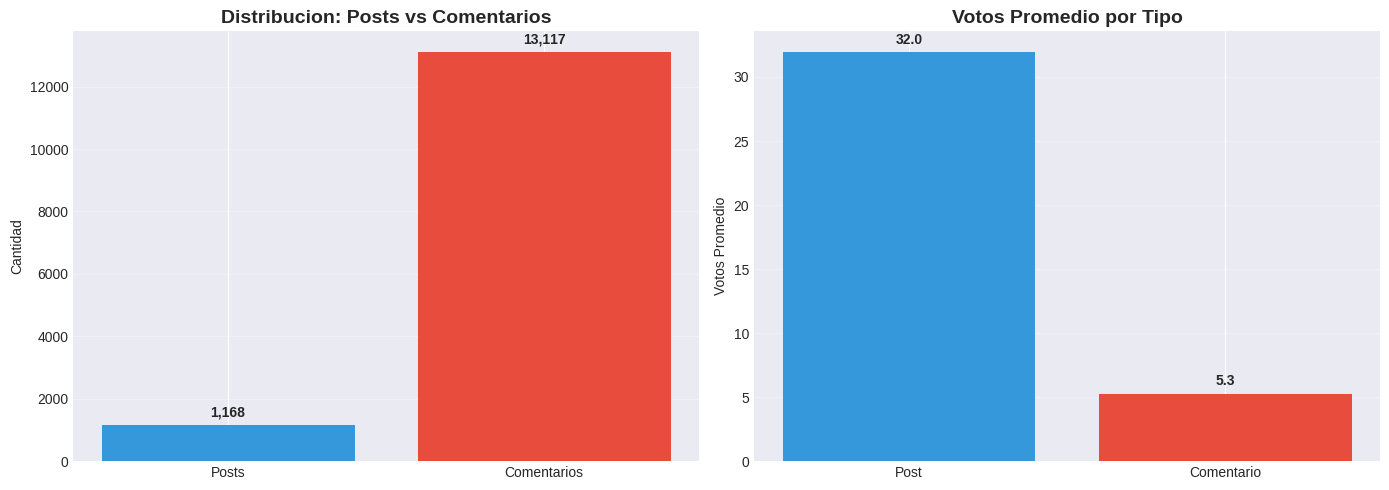

,Tipo,Cantidad,Votos Promedio,Votos Mediana,Votos Maximo,Palabras Promedio,Palabras Maximo
0,Post,1168,31.965753,10.0,579,179.280822,2103
1,Comentario,13117,5.275673,2.0,389,73.673096,1165


In [ ]:
df_tipo = distribucion_por_tipo(documents)
display(df_tipo)


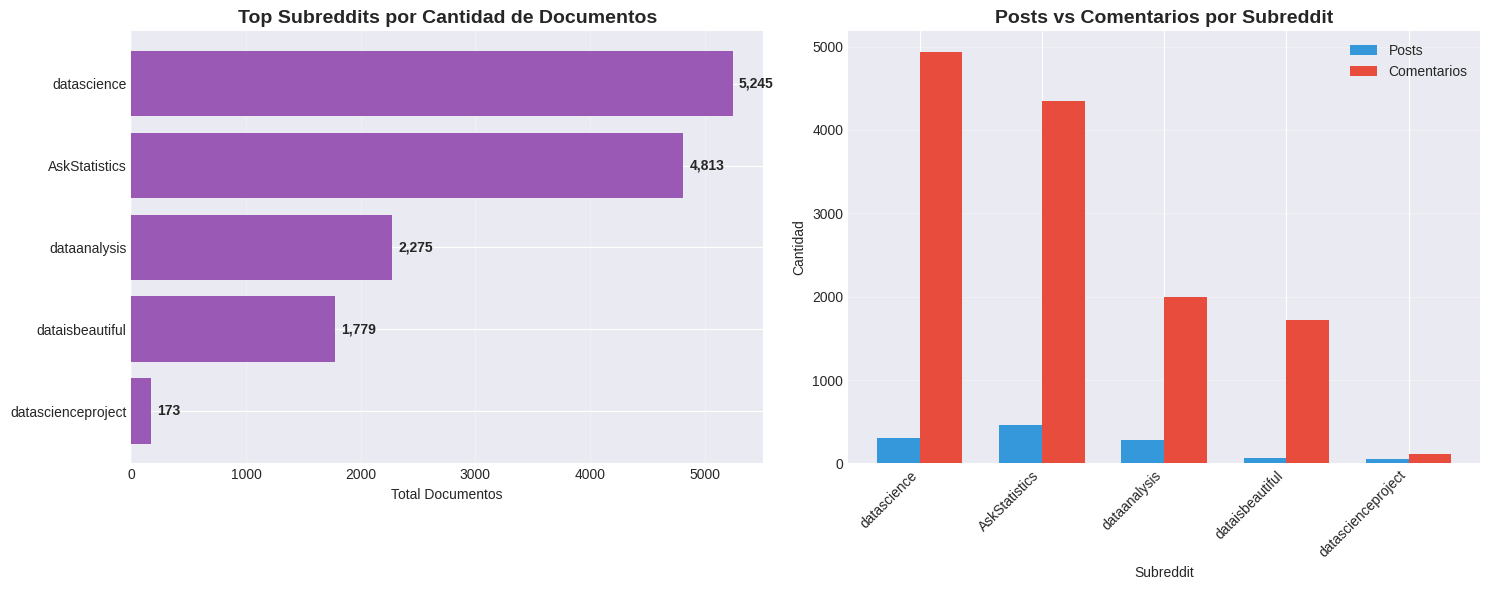

,Subreddit,Total,Posts,Comentarios,% del Total,Votos Promedio,Votos Maximo
0,datascience,5245,309,4936,36.716836,9.284271,478
2,AskStatistics,4813,465,4348,33.692685,4.361936,99
3,dataanalysis,2275,276,1999,15.925796,7.900659,521
4,dataisbeautiful,1779,61,1718,12.453623,10.427206,579
1,datascienceproject,173,57,116,1.211061,1.867052,11


In [ ]:
def distribucion_por_subreddit(documents):
    """
    Analiza la distribucion de documentos por subreddit.

    Returns:
        pd.DataFrame: DataFrame con estadisticas por subreddit
    """
    subreddit_data = defaultdict(lambda: {'posts': 0, 'comentarios': 0, 'votos': []})

    for doc in documents:
        subreddit = doc['metadata']['subreddit']
        tipo = doc['metadata']['type']
        votos = doc['metadata']['votes']

        if tipo == 'post':
            subreddit_data[subreddit]['posts'] += 1
        else:
            subreddit_data[subreddit]['comentarios'] += 1

        subreddit_data[subreddit]['votos'].append(votos)

    # Crear DataFrame
    data = []
    for subreddit, stats in subreddit_data.items():
        total = stats['posts'] + stats['comentarios']
        data.append({
            'Subreddit': subreddit,
            'Total': total,
            'Posts': stats['posts'],
            'Comentarios': stats['comentarios'],
            '% del Total': (total / len(documents)) * 100,
            'Votos Promedio': np.mean(stats['votos']),
            'Votos Maximo': max(stats['votos'])
        })

    df = pd.DataFrame(data)
    df = df.sort_values('Total', ascending=False)

    # Grafica
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Grafica 1: Total de documentos por subreddit
    top_n = min(10, len(df))
    df_top = df.head(top_n)

    axes[0].barh(df_top['Subreddit'], df_top['Total'], color='#9b59b6')
    axes[0].set_xlabel('Total Documentos')
    axes[0].set_title(f'Top Subreddits por Cantidad de Documentos', fontsize=14, fontweight='bold')
    axes[0].invert_yaxis()
    axes[0].grid(axis='x', alpha=0.3)

    # Agregar valores
    for i, v in enumerate(df_top['Total']):
        axes[0].text(v + max(df_top['Total']) * 0.01, i, f'{v:,}',
                    va='center', fontweight='bold')

    # Grafica 2: Posts vs Comentarios
    x = np.arange(len(df_top))
    width = 0.35

    axes[1].bar(x - width/2, df_top['Posts'], width, label='Posts', color='#3498db')
    axes[1].bar(x + width/2, df_top['Comentarios'], width, label='Comentarios', color='#e74c3c')

    axes[1].set_xlabel('Subreddit')
    axes[1].set_ylabel('Cantidad')
    axes[1].set_title('Posts vs Comentarios por Subreddit', fontsize=14, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(df_top['Subreddit'], rotation=45, ha='right')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    return df

# Ejemplo de uso:
df_subreddit = distribucion_por_subreddit(documents)
display(df_subreddit)

In [ ]:
def analisis_contenido(documents):
    """
    Analiza la longitud del contenido (palabras y caracteres).

    Returns:
        pd.DataFrame: DataFrame con estadisticas de contenido
    """
    posts = [d for d in documents if d['metadata']['type'] == 'post']
    comments = [d for d in documents if d['metadata']['type'] == 'comment']

    def calcular_stats(docs):
        palabras = [len(d['document'].split()) for d in docs]
        caracteres = [len(d['document']) for d in docs]
        return {
            'Palabras Promedio': np.mean(palabras),
            'Palabras Mediana': np.median(palabras),
            'Palabras Maximo': max(palabras),
            'Palabras Minimo': min(palabras),
            'Caracteres Promedio': np.mean(caracteres),
        }

    data = {
        'Tipo': ['Posts', 'Comentarios', 'General'],
        **{k: [v] for k, v in calcular_stats(posts).items()},
    }

    # Agregar stats de comentarios
    stats_comments = calcular_stats(comments)
    for k in stats_comments:
        data[k].append(stats_comments[k])

    # Agregar stats generales
    stats_general = calcular_stats(documents)
    for k in stats_general:
        data[k].append(stats_general[k])

    df = pd.DataFrame(data)
    df = df.round(2)

    # Distribucion por rangos
    all_words = [len(d['document'].split()) for d in documents]
    rangos = [
        ('< 50', lambda w: w < 50),
        ('50-100', lambda w: 50 <= w < 100),
        ('100-200', lambda w: 100 <= w < 200),
        ('200+', lambda w: w >= 200)
    ]

    dist_data = []
    for rango, condicion in rangos:
        cantidad = len([w for w in all_words if condicion(w)])
        porcentaje = (cantidad / len(all_words)) * 100
        dist_data.append({
            'Rango': rango,
            'Cantidad': cantidad,
            'Porcentaje': porcentaje
        })

    df_dist = pd.DataFrame(dist_data)

    # Graficas
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Grafica 1: Histograma de palabras
    words_posts = [len(d['document'].split()) for d in posts]
    words_comments = [len(d['document'].split()) for d in comments]

    axes[0].hist([words_posts, words_comments], bins=30,
                 label=['Posts', 'Comentarios'],
                 color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Numero de Palabras')
    axes[0].set_ylabel('Frecuencia')
    axes[0].set_title('Distribucion de Longitud de Contenido', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].set_xlim(0, 500)
    axes[0].grid(alpha=0.3)

    # Grafica 2: Distribucion por rangos
    axes[1].bar(df_dist['Rango'], df_dist['Cantidad'],
                color=['#1abc9c', '#3498db', '#9b59b6', '#e74c3c'])
    axes[1].set_xlabel('Rango de Palabras')
    axes[1].set_ylabel('Cantidad')
    axes[1].set_title('Documentos por Rango de Palabras', fontsize=12, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)

    for i, v in enumerate(df_dist['Cantidad']):
        axes[1].text(i, v + max(df_dist['Cantidad']) * 0.02,
                    f'{v:,}\n({df_dist["Porcentaje"].iloc[i]:.1f}%)',
                    ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    return df, df_dist

# Ejemplo de uso:
# df_contenido, df_contenido_dist = analisis_contenido(documents)
# display(df_contenido)
# display(df_contenido_dist)

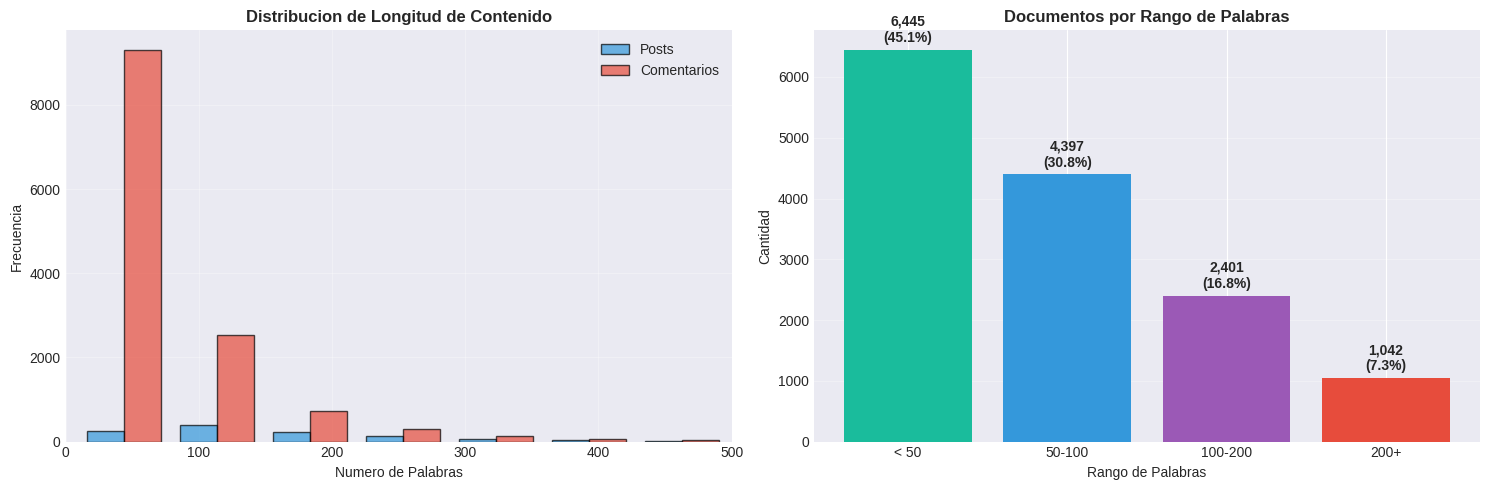

In [ ]:
df_contenido, df_contenido_dist = analisis_contenido(documents)

In [ ]:
display(df_contenido)
display(df_contenido_dist)

,Tipo,Palabras Promedio,Palabras Mediana,Palabras Maximo,Palabras Minimo,Caracteres Promedio
0,Posts,179.28,135.5,2103,23,1072.14
1,Comentarios,73.67,51.0,1165,9,437.64
2,General,82.31,55.0,2103,9,489.52


,Rango,Cantidad,Porcentaje
0,< 50,6445,45.117256
1,50-100,4397,30.780539
2,100-200,2401,16.807840
3,200+,1042,7.294365


In [ ]:
def resumen_ejecutivo(documents):
    """
    Genera un resumen ejecutivo completo con metricas clave.

    Returns:
        pd.DataFrame: DataFrame con todas las metricas principales
    """
    posts = [d for d in documents if d['metadata']['type'] == 'post']
    comments = [d for d in documents if d['metadata']['type'] == 'comment']

    all_votes = [d['metadata']['votes'] for d in documents]
    all_words = [len(d['document'].split()) for d in documents]

    subreddits = set(d['metadata']['subreddit'] for d in documents)
    authors = set(d['metadata']['author'] for d in documents)

    data = {
        'Categoria': [
            'DATASET',
            'DATASET',
            'DATASET',
            'DATASET',
            'DATASET',
            '',
            'CONTENIDO',
            'CONTENIDO',
            'CONTENIDO',
            '',
            'ENGAGEMENT',
            'ENGAGEMENT',
            'ENGAGEMENT',
            '',
            'COMUNIDAD',
            'COMUNIDAD'
        ],
        'Metrica': [
            'Total Documentos',
            'Posts',
            'Comentarios',
            'Subreddits Unicos',
            'Comentarios por Post',
            '',
            'Palabras Promedio',
            'Palabras Mediana',
            'Contenido Largo (200+ palabras)',
            '',
            'Votos Totales',
            'Votos Promedio',
            'Contenido Altamente Votado (50+)',
            '',
            'Autores Unicos',
            'Docs por Autor'
        ],
        'Valor': [
            f"{len(documents):,}",
            f"{len(posts):,}",
            f"{len(comments):,}",
            f"{len(subreddits):,}",
            f"{len(comments)/len(posts):.2f}",
            '',
            f"{np.mean(all_words):.0f}",
            f"{np.median(all_words):.0f}",
            f"{len([w for w in all_words if w >= 200]):,} ({len([w for w in all_words if w >= 200])/len(documents)*100:.1f}%)",
            '',
            f"{sum(all_votes):,}",
            f"{np.mean(all_votes):.2f}",
            f"{len([v for v in all_votes if v > 50]):,} ({len([v for v in all_votes if v > 50])/len(documents)*100:.1f}%)",
            '',
            f"{len(authors):,}",
            f"{len(documents)/len(authors):.2f}"
        ]
    }

    df = pd.DataFrame(data)

    # Estilizar el DataFrame
    print("="*60)
    print("RESUMEN EJECUTIVO DEL DATASET")
    print("="*60)

    return df

# Ejemplo de uso:
# df_resumen_ejecutivo = resumen_ejecutivo(documents)
# display(df_resumen_ejecutivo.style.set_properties(**{
#     'text-align': 'left',
#     'font-size': '11pt'
# }).hide(axis='index'))

In [ ]:
df_resumen_ejecutivo = resumen_ejecutivo(documents)
display(df_resumen_ejecutivo.style.set_properties(**{
    'text-align': 'left',
    'font-size': '11pt'
}).hide(axis='index'))

RESUMEN EJECUTIVO DEL DATASET


Categoria,Metrica,Valor
DATASET,Total Documentos,"14,285"
DATASET,Posts,"1,168"
DATASET,Comentarios,"13,117"
DATASET,Subreddits Unicos,5
DATASET,Comentarios por Post,11.23
,,
CONTENIDO,Palabras Promedio,82
CONTENIDO,Palabras Mediana,55
CONTENIDO,Contenido Largo (200+ palabras),"1,042 (7.3%)"
,,
